# ARGUS-FEDER — Answering GA's ELM competency questions

This notebook shows **ARGUS**, a notebook-native AI agent, answering questions
about **ELMs** (Edge Localized Modes) in DIII-D discharges. Questions are typed
in plain English into a `%%ask` cell; the agent decides what to look up, writes
and runs its own code, and reports back.

## What it is answering from

Stored ELM labels for DIII-D discharges, recording for each analysed shot:

- when the plasma was **ELMy** (continuous phases) and when **individual ELMs**
  fired, in milliseconds;
- **which method produced each label**, at which code version and with which
  parameters, so results from different methods stay comparable;
- **which D-alpha filterscope channels the shot actually had**, at what
  sampling rate, and why a channel was missing when it was.

Labels come from more than one source: detectors run at their authors'
committed parameters, unmodified, and sets of labels made by hand by a DIII-D
expert. The first question asks the system to enumerate them, with provenance.

Coverage grows as more shots are analysed, so the questions below ask the
system what it currently holds rather than assuming a fixed number.

## What the questions are

Sections A and B work through the **FEDER competency questions for ELM
detection** — a set of questions defining what a supporting data system should
be able to answer. Each is quoted **verbatim** before it is asked, so the
question and the answer can be judged together.

The questions are grouped as *science*, *data discovery* and *workflow*, and
are marked here as **answerable** (the index supports a complete answer) or
**partial** (it answers some of the question and the remaining gap is named).

Sections C and D go beyond that list — see their headers.

| section | questions | purpose |
|---|---|---|
| A | Q2, Q5, Q7, Q9, Q12 | answered completely from the index |
| B | Q3, Q4, Q11 | answered as far as the data allows; the gap is stated |
| C | four ad-hoc questions | the system is not limited to a fixed question list |
| D | two questions | where the correct answer is a refusal or a caveat |

Every `%%ask` cell is independent — run them in any order, or pick a few.

## A note on fetching

The index answers from stored results, so most cells return in seconds. Where a
question could be better answered by going to the DIII-D **Pelican** archive for
raw signal data, the agent is expected to **say so and offer**, with an estimate
of how much data and how long — and to wait rather than fetch unprompted.

## Prerequisites

1. **LLM key** — `NRP_API_KEY` in the environment, or a `.env` in the working
   directory.
2. **The ELM index** — `elm.sqlite`, placed in
   `~/work/_User-Persistent-Storage_CephBlock_/feder/` or `~/feder_data/`.
   Set `$ELM_DB_PATH` to point elsewhere.
3. **The DIII-D shot database** (`d3drdb.sqlite`) in the
   same folder — needed only where a question joins ELM labels to plasma
   parameters (Q4, Q11).
4. A **Pelican token** at `~/.fdp/token` only if you accept an offer to fetch
   raw data. Nothing in this notebook fetches without being asked.

Run the setup cell first to confirm the index is found.

# A. Questions answered completely from the index

## Q2 — What definition of an ELM does each detector implement?

*ELM · science · **answerable***

> **Competency question 2, as written:**
> What operational definition of an “ELM event” does a given detector implement (for example, a threshold on the rise rate of D-alpha), and what publication or documentation records that definition?

Labels from different methods are only comparable if each method's definition is
explicit. The index stores the method, its version and commit, and the full
parameter set, so this is answerable from provenance alone.

**Expect:** four labelling methods distinguished -- two detectors and two
sets of hand-made labels -- each attributed to a repository and commit, with
the detectors' real thresholds and merge times quoted.

In [2]:
%%ask --review
What ELM detection methods produced the labels available for DIII-D, and what
exactly does each one define as an ELM? Include the parameters and where each
method came from.

I'll start by planning this task, then consult the relevant skill.

Reading the skill file and its learned lessons now.

Reading the rest of the skill file and the learned lessons.

The skill's Rule 4 is directly relevant: report each detector's stored parameters and provenance, never invent the algorithm. Let me query the index for the run registry.

Writing a script to pull every run's full provenance and parameter set from the index.

...

Querying which label classes each run actually emits.

The row key differs from my alias — fixing to print raw rows.

That edit-and-retry hit a non-obvious dict-key behavior; recording it in Learnings.md before continuing.

All data gathered — five label sets across three automated methods and two expert sets. Completing the plan and reporting.

## ELM label sets available for DIII-D

Five label sets are stored, from three sources: one automated detector run at two granularities, two hand-labelled expert sets, and one independent automated detector. Two of the five are ground truth produced by a domain expert, not detector output — they are the yardstick the detectors are judged against, not another opinion.

**Overview**

| Label set | What produces it | Level | Shots covered | Labels stored |
|---|---|---|---|---|
| GA mode_classifier detector | automated detector | ELMy phases | 10,840 | 26,234 |
| GA mode_classifier detector | automated detector | individual ELMs | 10,840 | 1,318,684 |
| Expert regime labels | hand-labelled (ground truth) | ELMy phases | 397 | 2,333 |
| Expert ELM events | hand-labelled (ground truth) | individual ELMs | 23 | 326 |
| OMFIT ELM detector | automated detector | individual ELMs | 23 | 3,637 |

Per-shot coverage numbers are from the live index (10,917 shots indexed of the DIII-D archive, shot range 55102–207788; the index is a growing, non-uniform subset, not a census).

---

### 1. GA mode_classifier detector (method `slope_outlier`)

**Where it came from** : General Atomics' `mode_classifier` package — https://github.com/GA-FDP/mode_classifier at commit `b1b91d7`. It was run with GA's defaults, unmodified; the only patch was a compatibility fix for Python 3.12 / toksearch 2.x (PtDataSignal import, `toksearch.record.Record`, pandas `DataFrame.append`) with no algorithmic change.

**What it defines as an ELM** : a transient in the D-alpha filterscope signal. The detector reads one channel per shot — chosen as the best-signal-to-noise from `fs04da`, `fs03da`, `fs05da`, `fs04` — over 0–6000 ms, and labels each detection `ELMy H`. It is run twice with different merge settings, which produces two different products from the same detections:

- **ELMy phases** (run 1): continuous ELMy intervals, with consecutive detections merged when closer than `elm_merge_time = 200.0` ms. One row = a phase containing many ELMs.
- **Individual ELMs** (run 2): the same detections unmerged (`elm_merge_time = 0.0`), so one row = one ELM burst.

**Full parameter set** (identical in both runs except the merge time):

| Parameter | ELMy phases | Individual ELMs |
|---|---|---|
| `pos_deriv_thresh` | 2.7 | 2.7 |
| `neg_deriv_thresh` | 0.9 | 0.9 |
| `lowpass_cutoff_freq` | 2000.0 | 2000.0 |
| `filter_type` / `filter_size` | mean / 5 | mean / 5 |
| `causal` | false | false |
| `elm_merge_time` (ms) | 200.0 | 0.0 |
| `start_padding` / `end_padding` (ms) | 1.0 / 1.0 | 1.0 / 1.0 |
| `time_range` (ms) | 0.0–6000.0 | 0.0–6000.0 |
| `signal_list` | fs04da, fs03da, fs05da, fs04 | same |

The parameters record thresholds on the derivative of a filtered D-alpha signal, but what the thresholds are normalised against and the order of operations live in the source repo, which is not installed in this environment — the internal algorithm must be read from `mode_classifier@b1b91d7`, not reconstructed from parameter names. (The skill's documentation notes the reference detector fits a **gamma** distribution for its baseline — it is not MAD-normalised.)

**Important caveat on interpretation** : a label from this detector means "D-alpha transients were detected", not "the discharge was in ELMy H-mode". It almost never declines — of the 10,840 shots it ran on, 9,552 were labelled, only 119 came back with nothing found, 856 had no data and 313 errored — and it labelled every expert-confirmed QH-mode (by definition ELM-free) discharge it was validated against, because QH-mode carries real edge D-alpha activity.

### 2. Expert regime labels (method `human_regime`)

**Where it came from** : hand-labelled by a DIII-D domain expert; version `labels_20241025`, distributed in the GA-FDP/mode_classifier repository as `meta_data/QHMode_latest_new_elms.csv` (an alternative coarser cut of the same labels exists in `meta_data/QHMode_latest.csv`). Ground truth, covering 397 shots.

**What it defines as an ELM** : this set does not define individual ELMs at all — it is confinement-regime windows, a different kind of statement. A window asserts "the plasma was in this regime from t1 to t2". The regimes marked, and what each means:

| Class | Meaning | Windows |
|---|---|---|
| ELMy H | ELMing H-mode — the plasma IS producing ELMs | 1,476 |
| QH | Quiescent H-mode — good confinement, no ELMs, edge oscillates instead | 471 |
| WPQH | Wide-Pedestal Quiescent H-mode | 260 |
| BBQH | Broad-Band Quiescent H-mode | 126 |

(The labeller's code list also defines QM = Quiet Mode and WBQH = Wash-Board Quiescent H-mode; unlabelled time was explicitly "L-mode background, not labeled" — meaning L-mode was never marked, not that unmarked time is L-mode.) So "ELM" here means: an expert watched the discharge and marked intervals where ELMs were being produced. Narrow ELMy H intervals are nested inside broad quiescent spans, marking ELM clusters within otherwise quiescent phases.

### 3. Expert ELM events (method `human_elm_events`)

**Where it came from** : hand-labelled by a domain expert; `ELM_database.json` from https://github.com/GA-FDP/elm_detection_challenge at commit `44b723c`. Ground truth for 23 DIII-D cases.

**What it defines as an ELM** : an individual ELM, marked by hand, with each event typed. 326 events across the 23 shots (17 shots labelled, 6 honestly marked as having none): type2 = 211, type1 = 81, type4 = 25, type3 = 8, type5 = 1. The type codes 1–5 are present in the data but their meanings are **not documented upstream** — an open question for GA, so I can't tell you what distinguishes a type2 from a type4. Each shot is labelled only within its graded window (tstart..tend), not the whole discharge, and each event carries a per-endpoint timing uncertainty that this index has nowhere to store (it was dropped rather than misfiled).

### 4. OMFIT ELM detector (method `omfit_elm`)

**Where it came from** : an adaptation of the ELM detector from the OMFIT framework, run as part of the https://github.com/GA-FDP/elm_detection_challenge at commit `44b723c` — the same 23 cases as the expert event set, so the two can be compared directly. It was run locally (not by GA), with fetches redirected through a Pelican mirror; the detector itself was unmodified.

**What it defines as an ELM** : a burst in the summed light of filterscope chords near the divertor strike point. Stored configuration:

- **`detection_method`: 1** , named **"jump and hold"** (the stored method name; the mechanics live in the OMFIT source)
- **`operation`** : sum of selected chords
- **`channel_selection`** : geometric — the detector's own geometry code picks filterscope chords near the divertor strike point, from 18 candidates (FS00–FS08, FS12, FS00UP–FS04UP, FS11UP–FS13UP)
- **`scope`** : clipped to each case's graded window for comparability with the expert events
- labels every detection simply `ELM` (3,637 events over the 23 cases; 15 shots labelled, 4 with nothing found, 4 errored)

The four failures are structural, not physics: with no plasma there is no EFIT equilibrium, so the strike points are empty and the geometric chord selection cannot run. Those zeros are failures and must not be read as "found no ELMs".

---

**A note on comparability** : the two granularities of the GA detector are different products (phases vs individual ELMs) and their counts are never comparable; likewise the regime windows of the expert labels are a different kind of statement from any event list. The GA detector's event start times also run roughly a millisecond earlier than the expert's on shots where both exist — irrelevant for counting ELMs, but the same size as the effect in any pre-ELM lead-time measurement, so any such result should say which label set it used. All times in this index are milliseconds.

## Q5 — Which D-alpha channels exist for a shot, and where?

*ELM · data discovery · **answerable***

> **Competency question 5, as written:**
> For shot N, which pointnames carry D-alpha filterscope data, and which shotfile (or tree or archive location) holds each one?

**Expect:** the candidate channels for shot 165286 with sample counts, sampling
rates and units. Times are in milliseconds.

In [3]:
%%ask --review
For DIII-D shot 165286, which D-alpha filterscope channels are available in the
ELM index, how many samples does each have, and at what sampling rate?

Reading the skill instructions and its learned pitfalls before querying.

The skill and its learned pitfalls are loaded. Now I'll write a small script that queries signal availability for shot 165286, with NULL guards on `rate_khz` per the Learnings.

Running the query script for shot 165286.

The query ran cleanly — all four channels present. Marking the work complete and reporting.

## Filterscope availability for DIII-D shot 165286

All four D-alpha filterscope channels tracked for this shot are present and fully usable. Availability was checked against the stored signal-availability metadata recorded alongside the ELM labels.

| Channel | Present | Samples | Sampling rate | Time coverage (ms) | Units |
|---|---|---|---|---|---|
| fs03da | yes | 300,000 | 49.9512 kHz | 0.02 – 6000.0 | ph/cm²/sr/s |
| fs04 | yes | 300,000 | 49.9512 kHz | 0.02 – 6000.0 | ph/cm²/sr/s |
| fs04da | yes | 300,000 | 49.9512 kHz | 0.02 – 6000.0 | ph/cm²/sr/s |
| fs05da | yes | 300,000 | 49.9512 kHz | 0.02 – 6000.0 | ph/cm²/sr/s |

**Details worth noting** :

- The 49.9512 kHz figure is the *measured* rate, derived from the median sample spacing, so it sits just under the nominal 50 kHz — not an anomaly. The full-discharge record (0.02 ms to 6000 ms = 6 s at ~50 ksamples/s) matches the 300,000-sample count exactly, so each channel spans the whole discharge with no gaps in the metadata.
- All four channels share identical sample counts, rates, and time bases, so they are directly comparable sample-for-sample.
- Units are photon flux (ph/cm²/sr/s) — that describes the data values, not the time axis.
- For context on how these were used: the GA mode_classifier detector ranked these four channels by signal-to-noise for this shot and selected **fs03da** (SNR 36.2 dB) as its input, producing 274 individual ELM labels and 2 ELMy-phase intervals across the discharge.

## Q7 — Across a shot range, which shots have the required channels?

*ELM · data discovery · **answerable***

> **Competency question 7, as written:**
> Across a shot range (say 190000 to 195000), which shots have the full required set of filterscope pointnames archived?

The range below is the one named in the question itself. The interesting part is
the treatment of coverage: shots the index has never examined must be reported
as **unknown**, not as missing.

**Expect:** the shots that have both channels, an explicit count of how many in
the range were actually checked, and — per the note above — an offer to fetch
the rest rather than a bare "unknown".

In [4]:
%%ask --review
For DIII-D shots between 190000 and 195000, which ones have both the fs04da and
fs03da filterscope channels available? Be explicit about how many shots in that
range have actually been checked, and do not treat an unchecked shot as one
without data.

Reading the remaining lines of the skill file and its learned-error notes.

The skill documents this exact range-question workflow (`shots_with_signals`, d3drdb population count, `fetch_estimate` offer). Writing the query script now.

All 23 checked shots have both channels. One small discrepancy to resolve: `fetch_estimate` counted 22 already-indexed but 23 shots have availability rows — checking which shot differs.

Both channels are present on all 23 checked shots; the 23-vs-22 count difference is just `fetch_estimate`'s bookkeeping (shot 192855 is indexed but omitted from its already-indexed list). Completing the plan and reporting.

## fs04da + fs03da availability, shots 190000–195000

**How many shots were actually checked** : only **23** of the 3,507 plasma shots that exist in this range (per the DIII-D shot database) have ever been fetched and checked for filterscope availability. The other **3,484 shots have never been checked** — their availability is unknown, and none of them should be read as lacking data.

**Of the 23 checked shots, all 23 have both fs04da and fs03da** (and in fact all four tracked D-alpha channels are present on every one of them). None was checked and found to lack either channel.

| Shot | fs04da | fs03da | Rate (both) | Coverage |
|---|---|---|---|---|
| 190067 | present | present | 99.902 kHz | 0–6000 ms, 600,001 samples |
| 190300 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 190516 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 190731 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 190943 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 191235 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 191497 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 191728 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 191955 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 192048 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 192179 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 192425 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 192753 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 192855 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 193017 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 193289 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 193690 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 193923 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 194201 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 194425 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 194479 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 194715 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |
| 194948 | present | present | 49.951 kHz | 0–6000 ms, 300,001 samples |

Rates are the measured values (derived from median sample spacing); 49.951 kHz and 99.902 kHz are the nominal 50 kHz and 100 kHz. All 23 channels span the full 6-second digitizer window, so every record is genuinely usable for ELM work, not merely present.

One caveat on the checked subset: these 23 shots were not sampled uniformly across the range (they sit roughly evenly spaced, with a tighter cluster near 194.4k), so "23/23 have both channels" describes the checked subset, not the range as a whole.

I can fetch the filterscope data for the 3,484 unchecked shots to complete the range — that would transfer about **108 GB (31 MB/shot across the wire, 9.6 MB/shot decoded)** and take roughly **81 minutes serially, or about 53 minutes with 8 parallel workers** . A narrower sub-range would cost proportionally less — for example, 190000–191000 alone would be roughly 20× smaller. Shall I proceed, and if so over the full range or a slice?

## Q9 — Is the sampling rate high enough to resolve individual ELMs?

*ELM · data discovery · **answerable***

> **Competency question 9, as written:**
> Do the candidate signals have enough sampling rate and time coverage to resolve individual ELMs (roughly kHz)?

Because the rate is stored per shot and channel, this can be asked of the whole
population at once, including the shots where the answer is **no**.

**Expect:** a distribution dominated by 50 kHz and 100 kHz — far above the ~1 kHz
ELM rate — plus an explicitly flagged slow tail that cannot resolve ELMs.

I'll read the skill instructions and its learnings first, then query the index.

The first run surfaced the rate distribution but crashed on a malformed scratch query I left in (a dummy subquery with no `shot` column). The key facts so far: all sub-5 kHz channels are `fs04` in the 100000–130187 era, plus 41 shots where `fs04` is a single-sample stub. Now I'll fix the script and add the adequacy analysis.

The core distributions are in, but I caught a bug before reporting: my percentile helper was fed **unsorted** lists for the ELM frequency/period/burst stats (it produced an impossible p75 < p25), and I need era details for the ~10 kHz and 20 kHz groups. Fixing with a follow-up script.

All numbers are in and reconciled (the per-shot family counts sum exactly to the 9,984 shots with data). Updating the plan, then recording the lessons from the two fix-and-rerun cycles before the report.

All reconciled — the families sum exactly to the 9,984 shots with present data. One last small query to pin down the era ranges of the ~10 kHz and ~1 kHz families so the report's era statements are quoted, not inferred.

...

One inconsistency to settle: my earlier bin edges didn't cleanly separate the 20 kHz family, so the by-shot bin table needs recomputing with unambiguous edges before I quote it.

The bin table reconciled: the "43" bucket is actually 2 genuinely sub-0.35 kHz shots plus 41 degenerate stubs that the SQL CASE dumped into the else-branch. Final step: sample the detector's recorded error text for the slow shots and write the full slow-shot list to a CSV the user can open.

The detector's own recorded error confirms the verdict on all 259 slow shots. Two last steps: verify the small denominator gap (shots with no availability record), and render a distribution chart.

That placeholder draft had a typo — writing the real chart script now.

## Filterscope sampling rates across the stored DIII-D ELM labels

**Short answer** : the rates split into fast (50/100 kHz — 9,337 of 9,984 shots with data), adequate (10/20 kHz — 347 shots), and a slow legacy tail (≤2 kHz — 259 shots, all before shot 130883, where only the old `fs04` channel exists). Individual ELMs on DIII-D, as actually labelled here, recur at tens to hundreds of Hz with ~5 ms bursts — so 10 kHz and above resolves them comfortably, 2 kHz is marginal, and the 0.1–1 kHz tail cannot. Every one of the 259 slow/degenerate cases was already rejected by the detector's own 2 kHz lowpass requirement, so no ELM labels exist for them.

All figures below are from the 10,917 indexed shots (a growing, non-uniform subset of the archive, not a census); 10,840 have signal-availability records, of which 9,984 have at least one present channel. Rates are **measured** (median sample spacing), which is why each nominal rate appears in near-duplicate pairs (50 & 49.951 kHz, 100 & 99.902 kHz).

**Fastest available channel per shot:**

| Fastest rate | Shots | Share of shots with data | Verdict for individual ELMs |
|---|---|---|---|
| 100 kHz (99.902 kHz measured) | 4,067 | 40.7% | resolves comfortably |
| 50 kHz (49.951 kHz measured) | 5,270 | 52.8% | resolves comfortably |
| 10 kHz (9.996 kHz measured) | 311 | 3.1% | resolves; timing precision ~0.1 ms |
| 20 kHz (19.98 kHz measured) | 36 | 0.4% | resolves comfortably |
| 2 kHz | 1 | 0.01% | marginal — one shot, 108878 |
| 1 kHz | 58 | 0.6% | too slow |
| 0.5 kHz | 198 | 2.0% | too slow |
| 0.1 / 0.2 kHz | 2 | 0.02% | far too slow |
| degenerate (single sample, rate undefined) | 41 | 0.4% | unusable |

Two structural facts explain the whole distribution: the three "da" channels (`fs03da`, `fs04da`, `fs05da`) exist only from shot **130882** onward and never run below 10 kHz; before that, only `fs04` exists, and in that era it was digitized at 0.1–2 kHz. No shot mixes rates across its present channels — whatever rate a shot's fastest channel has, all its present channels share it. One anomaly: shot **131672** has all four channels at a measured **82.96 kHz** , matching neither nominal rate.

### Is it fast enough? Grounding the criterion in the stored labels themselves

"Roughly kHz" overstates DIII-D ELM rates as labelled here. From the GA mode_classifier detector's stored burst labels (9,552 labelled shots):

- **ELM frequency while ELMing** : median 58.5 Hz, p95 124.1 Hz, **maximum 434.8 Hz** — not one of 9,552 shots reaches 1 kHz.
- **Mean ELM period** : median 17.1 ms, p95 44.3 ms, minimum 2.3 ms.
- **Mean burst duration** : median 4.74 ms, p95 11.2 ms.
- The closest consecutive ELMs on any single shot are **2.04 ms** apart.

Against those numbers:

- **50/100 kHz** gives a sample every 20/10 µs — 100–500 samples across a median burst; ELM rise and fall are both resolved. Yes.
- **10 kHz** (a sample every 100 µs) puts ~47 samples inside a median burst and ~170 between median-spaced ELMs — individual ELMs are cleanly separable, with event timing quantised to ~0.1 ms. Adequate. This cohort spans shots 130884–138690 (mostly early-130k commissioning of the fast digitizers).
- **2 kHz** (Nyquist 1 kHz): a median burst spans ~9 samples, and the detector's own 2 kHz lowpass cutoff cannot be applied — it recorded exactly that reason when refusing this shot. Marginal at best.
- **≤1 kHz** : a sample every 1–10 ms. At 1 kHz a median burst spans ~5 samples; at 0.5 kHz, ~2; ELMs spaced as closely as 2–3 ms merge entirely. Not resolvable.

### The shots where the rate is too low — all 300, listed

The full per-shot list with per-channel rates, sample counts, and the detector's recorded error is saved as `slow_rate_shots.csv` in the working directory (300 rows). The pattern:

| Group | Shots | Range | Detail |
|---|---|---|---|
| 0.5 kHz (fs04 only) | 198 | 104320–130187 | includes a contiguous block of 166 shots, 130000–130187 |
| 1 kHz (fs04 only) | 58 | 100161–122073 | |
| 2 kHz (fs04 only) | 1 | 108878 | the marginal case |
| 0.1 / 0.2 kHz | 2 | 101056; 123214 | |
| degenerate fs04 stub | 41 | 94822–131138 | `fs04` exists as a single sample at t=0 ms — present but meaningless |

In every one of the 259 rate-limited cases the only channel on the shot was `fs04`, the other three channels are absent, and the detector's run status is `error` with the recorded reason *"no usable channel — fs04: sampling 0.5/1.0/2.0/0.1/0.2 kHz too low for a 2000 Hz lowpass"*. So these shots carry **no ELM labels at all** — that is why the slow tail matters: pre-130883 discharges are effectively outside the labelled set, not mislabelled. A further 856 indexed shots have no present channel of any kind, and 77 have no availability record at all.


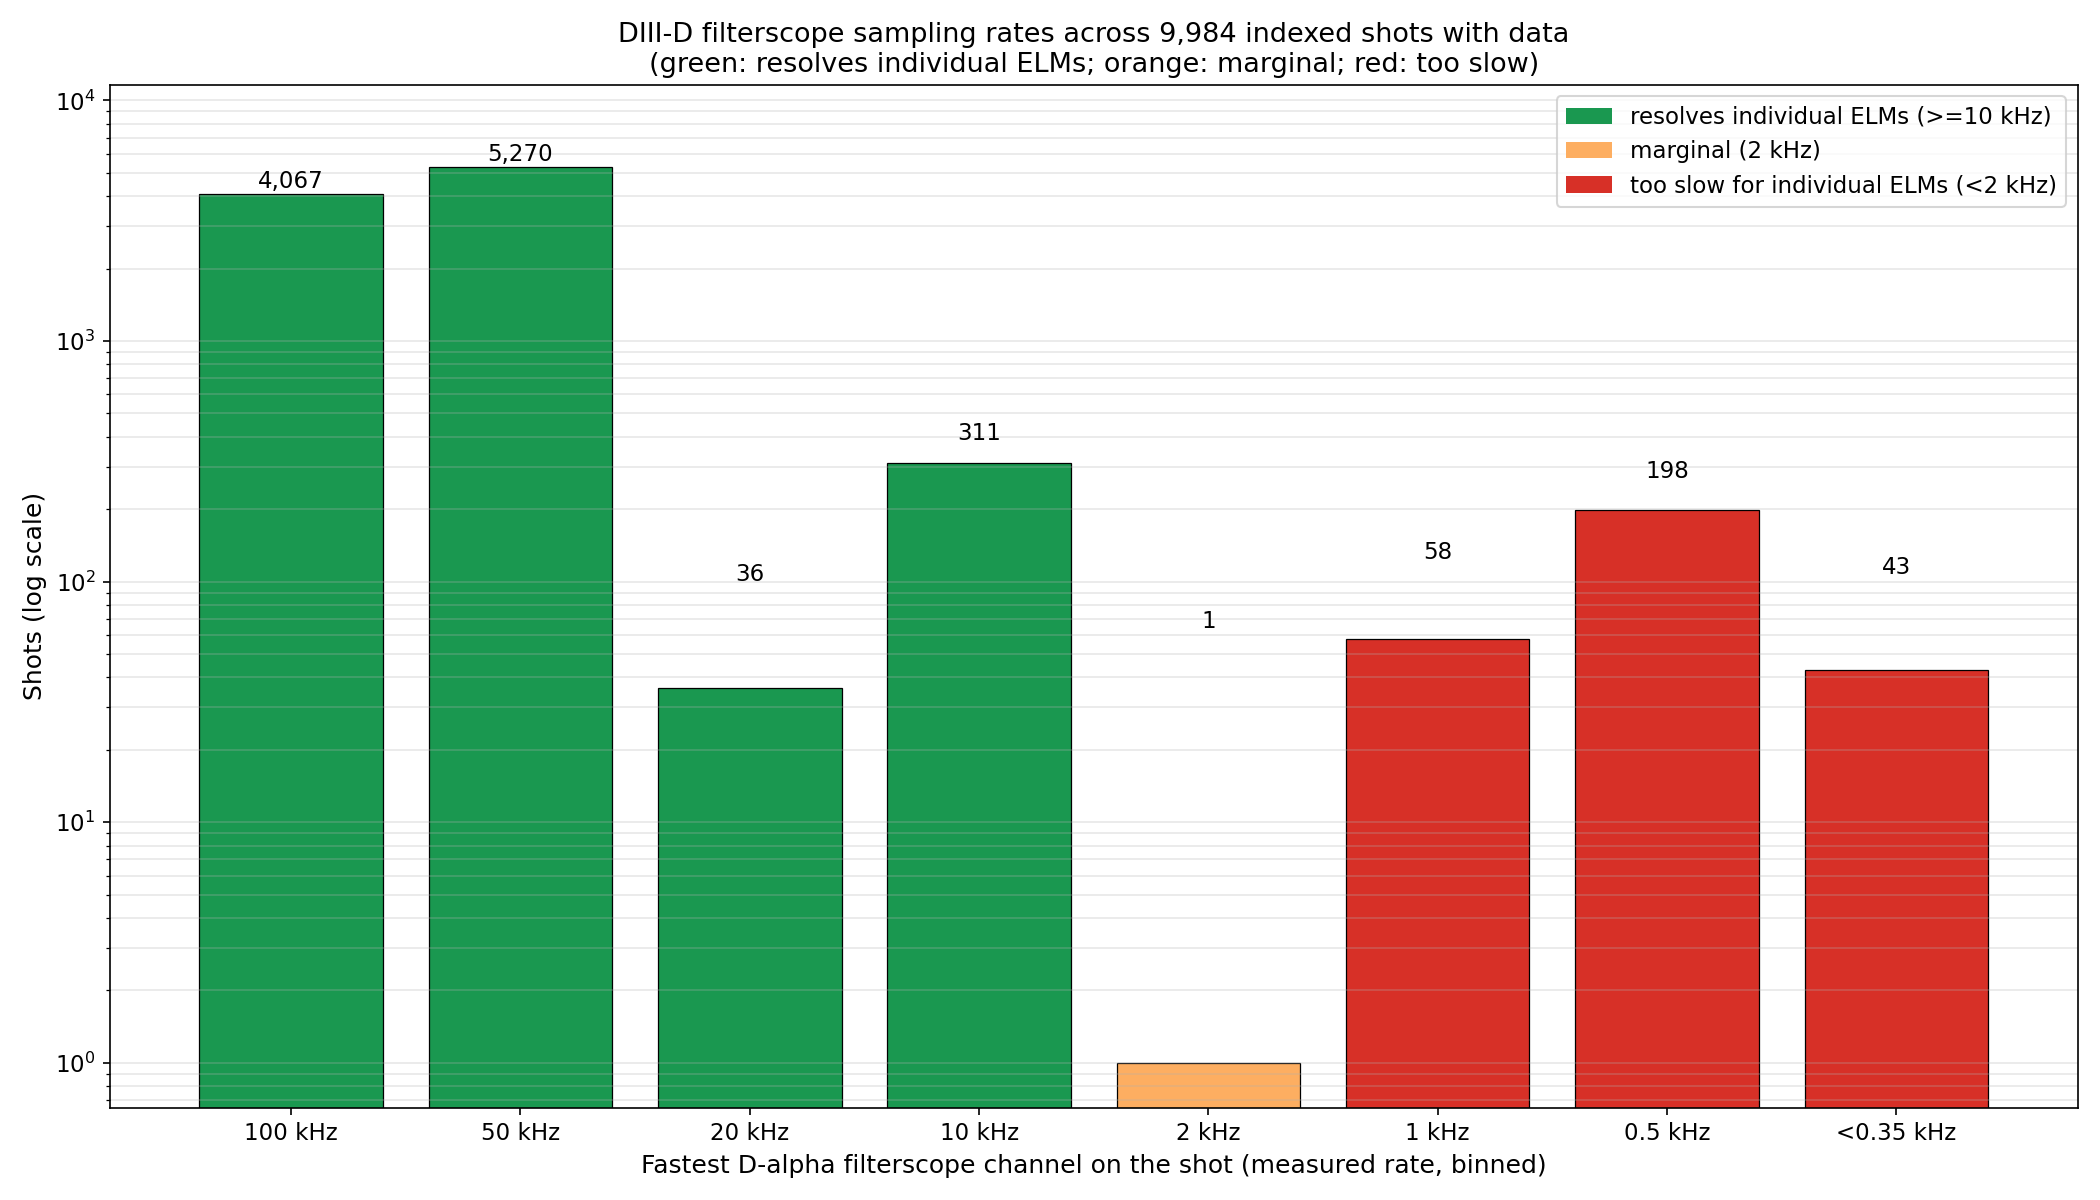

**Caveats** : shares are of the 9,984 indexed shots with present data, and the index is a non-uniform subset of the archive (Rule of reporting: these are not archive-wide percentages). The 10 kHz adequacy verdict is conditional on the stored burst statistics; for any analysis needing burst *shape* rather than event timing, 10 kHz is the floor, not a comfortable margin.

If you want to see for yourself what a slow-era record actually contains — say shot 108878, the lone 2 kHz marginal case, or a 0.5 kHz shot like 130050 — I can fetch its raw D-alpha trace (about 31 MB transferred, ~1.4 s each) and plot it. That would confirm what the archive holds, though it cannot change the digitization rate: the 0.5/1 kHz era is a property of the data, not a gap in it. Shall I?

In [5]:
%%ask --review
Across all shots in the ELM index, what sampling rates do the filterscope
channels have? Is that fast enough to resolve individual ELMs, which occur at
roughly kHz rates? Point out any shots where the rate is too low.

## Q12 — Validate a detector against an existing label set

*ELM · workflow · **answerable***

> **Competency question 12, as written:**
> Validate a new detector. Which shots have both the raw D-alpha signals and an existing ELM label set from a prior pipeline? Fetch both and report where the detectors disagree.

This is the question the system was designed around: several label sets stored
side by side, each traceable to the run that produced it.

**Expect:** the best-covered shot chosen by the system, the methods compared
only where they make the same kind of claim, and disagreement reported against
the hand-made labels rather than between detectors alone.


I'll validate the detectors by cross-referencing shots carrying labels from multiple methods. Let me plan this out first.

Re-reading the skill files to refresh the exact query API before writing any code.

Reading the remaining lines of the skill plus its Learnings.md, which is mandatory for this skill.

Skill and learnings refreshed. Key APIs: `shots_with_multiple_sources()`, `compare_on_shot()`, `events_by_regime()`, `plot_comparison()`. Now I'll write the validation script — first finding which shots carry labels from multiple methods including hand-made ones.

Writing the shot-coverage query script.

...

Typo in my old_string ("real real"). Retrying with the exact text.

The edit keeps failing on exact-match; I'll rewrite the small Learnings file wholesale, preserving its content and appending the new lesson.

Learnings recorded. Verifying the output files exist for embedding (glob only, no image reading).

Before writing the report, verifying the figure was produced with the skill's canonical `plot_comparison` rather than a hand-built chart.

## Validating the detectors against existing label sets

### Which shots carry labels from more than one method

Fifty shots in the stored labels (of 10,917 indexed) are covered by more than one method, and **every one of the fifty includes at least one hand-made set** . They fall into three tiers:

| Coverage | Shots | Methods available |
|---|---|---|
| 4 methods | 1 | both hand-made sets (expert ELM events + expert regime labels) + both detectors (GA mode_classifier, OMFIT) |
| 3 methods | 22 | expert ELM events + GA mode_classifier detector + OMFIT ELM detector |
| 2 methods | 27 | expert regime labels + GA mode_classifier detector |

- **The one 4-method shot: 163518** — the single case where event-level ground truth, regime-level ground truth, and two independent detectors all exist.
- **The 22 3-method shots** (event-level validation set): 132651, 141474, 154749, 158115, 161202, 161558, 165703, 166828, 169908, 171322, 172186, 180257, 180264, 180445, 192048, 192855, 194479, 203788, 204116, 206709, 207173, 207788.
- **The 27 2-method shots** are one contiguous cluster, 149058–149172: these have regime windows but no expert event list, so only phase-level comparison is possible there.

### Best-covered shot: 163518

The only shot with all four label sets, so it is the fullest validation case. The GA detector read channel fs04da at SNR 36.0 dB — a clean signal, so what follows is not a signal-quality artifact. The expert's regime timeline marks 361 ms as ELMy H, 1,281 ms as QH, 2,235 ms as WPQH (3,516 ms quiescent total, 2,123 ms with no regime marked).

**Headline counts on the same 0–6000 ms window:** the expert hand-marked **5 ELMs** ; the OMFIT detector found **8** ; the GA mode_classifier detector found **91** .

### Where the methods disagree

Matching every expert event to the nearest detector event (my convention: greedy nearest start time, 20 ms tolerance — the conclusion below does not hinge on this choice):

**Event-level, against the expert's 5 ELMs:**

| Metric | GA mode_classifier | OMFIT |
|---|---|---|
| Recall | 4 of 5 | 5 of 5 |
| Precision | 4 of 91 = 4.4% | 5 of 8 = 62.5% |
| Start-time offset vs expert | −2.6, +5.0, −11.2, −3.8 ms | within ±0.75 ms throughout |
| Typical event duration | 7.6–12.2 ms (smeared) | 0.2–3.7 ms (matches expert's 0.3–4.1 ms) |

- **OMFIT tracks the expert almost exactly** : all five events reproduced, start times within 0.75 ms, durations of the same scale. Its three extra events (at ~520.6, ~526.2 and ~5662.4 ms) are its only disagreement.
- **The GA detector's one miss is a merge, not a miss** : at 5660.91 and 5663.87 ms the expert marked two separate ELMs (type5 then type4) and OMFIT found three spikes; the GA detector produced a single burst spanning 5657–5667 ms. Its burst-like output merges closely spaced ELMs and starts several milliseconds early — consistent with the population-level note that its event starts run roughly a millisecond or more ahead of the expert's.
- **The GA detector's 87 extra events are the real disagreement** : 37 fall in expert-marked WPQH, 7 in expert-marked QH, 35 inside expert ELMy H windows (where the expert implied ELMs but hand-listed none — the hand event list for this shot names only 5), and 8 in unlabelled time. So 44 of 91 detections sit in time the expert called quiescent.

**Phase-level, GA ELMy phases vs expert ELMy H windows:** the two agree exactly in one direction — all 361 ms the expert marked ELMy H lie inside GA "ELMy" phases. The reverse fails badly: the GA phases total 2,434.7 ms, of which 1,878 ms (77%) lie in expert-marked quiescent regimes (1,358.9 ms in WPQH, 519.1 ms in QH) and 195.9 ms in unlabelled time.


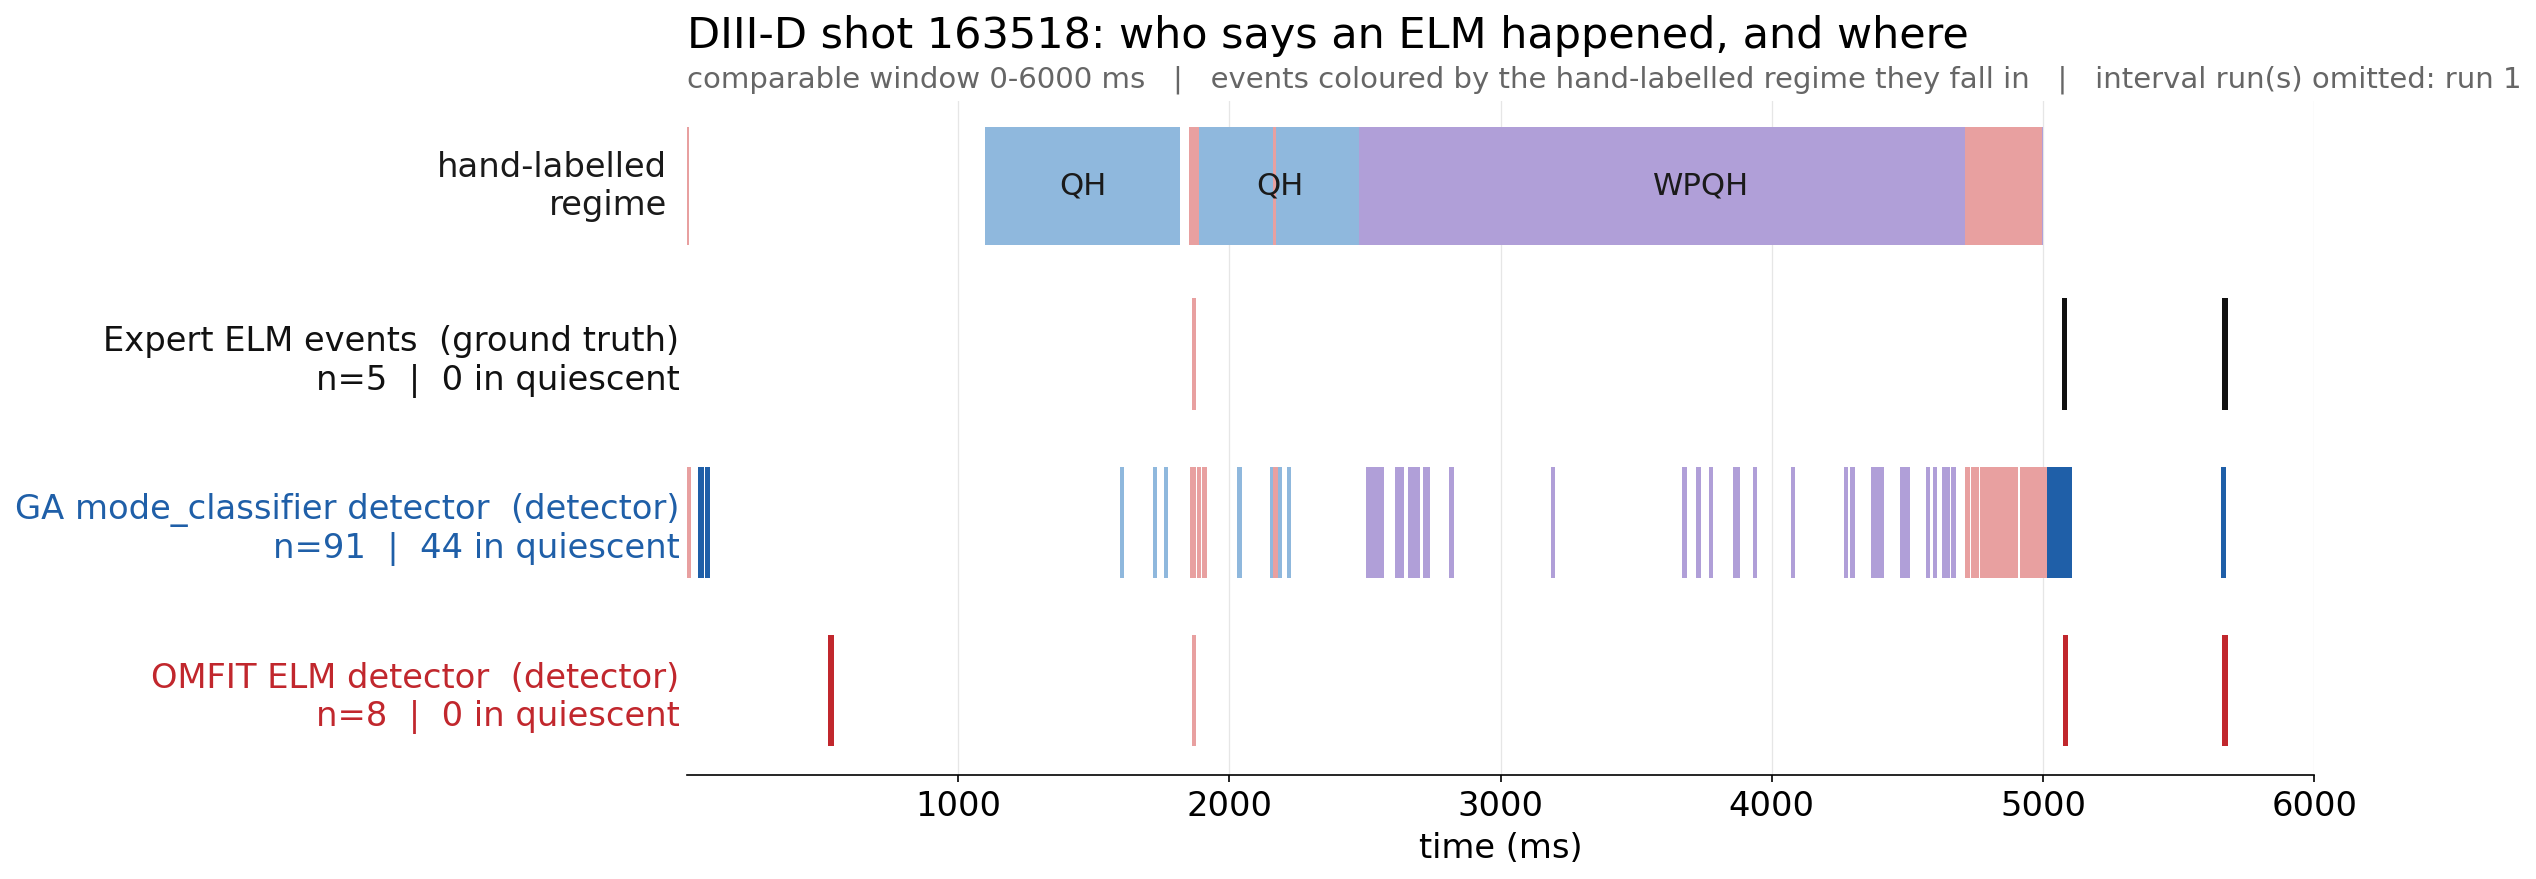

### Validation verdict

- **OMFIT validates well** : near-perfect recall, sub-millisecond timing agreement, matched durations. On this shot its errors are a handful of extra small events.
- **The GA mode_classifier detector does not separate ELMing from quiescent periods** : it fires 91 times where a human counted 5 ELMs, and more than half its detections land in regimes the expert marked as having no ELMs. This is the known over-labelling behaviour, and shot 163518 shows its mechanism concretely — merged, early-starting, long bursts — on a high-SNR channel. Population-wide (320 shots where it overlaps the expert regime labels) it fires 34.2 events/s in ELMy H against 1.8/s in QH, so the signal it tracks is real, but per-shot its event list should not be read as "the ELMs that occurred".
- One caveat cuts the other way too: the expert regime labels are one person's assertion about dominant behaviour, not an impossibility proof — a quiescent label does not guarantee zero ELMs in that window, so some of the GA detector's quiescent-phase detections could be genuine small ELMs the expert classed as background.

All event-level numbers above are conditional on the expert ELM event list for shot 163518; the regime-level numbers on the expert regime labels — the two alternatives available on this shot were named throughout (each conclusion used the ground-truth set as yardstick, which is the point of validation).

If you want to adjudicate the disputed events directly, I can fetch the raw D-alpha trace for 163518 (~31 MB transferred, ~1.4 s) and overlay it on this comparison figure, so the expert's 5 events, OMFIT's 3 extras and the GA detector's quiescent-phase detections can all be seen against the actual signal. Shall I?

In [6]:
%%ask --review
Validate the detectors against an existing label set. Which shots have labels
from more than one method, including hand-made ones? Pick the best-covered shot
and report where the methods disagree

---
# B. Questions the index answers only partly

These are included deliberately. The competency-question exercise treats a
question that cannot be fully expressed as evidence of a **modeling gap**, so
the useful output is the part that works *plus* a clear statement of what is
missing — not a confident-sounding half-answer.

## Q3 — When were ELMs occurring, and when were they suppressed?

*ELM · science · **partial***

> **Competency question 3, as written:**
> For a given shot, during which time windows was the plasma in a regime where ELMs are possible (H-mode), and in which windows was ELM activity suppressed or absent (RMP suppression, QH-mode)?

**Expect:** the expert's regime windows for a shot that has them — ELMy phases and quiescent ones, with QH, wide-pedestal QH and broadband QH named as distinct states. Then the limits, which differ per case: L-mode is never marked explicitly (the source treats it as unlabelled background, so quiet-and-unmarked is ambiguous), and no expert marked RMP suppression — for that, the agent should offer to fetch the suppression-coil currents, and say that calling a current "suppression" needs a threshold from the facility. A good answer separates "the expert said quiescent here" from "nobody said anything here", and does not read the second as the first.

I'll pick the best-covered shot with expert regime labels — 163518, the 4-method shot from the validation step — and lay out its annotated regime timeline. Planning first.

Reading the skill and its learned lessons before writing any code.

Reading the remaining lines of the skill, plus its Learnings file (this skill has one).

Skill and lessons read. The user asked about "a shot where an expert marked the regimes" without naming one — per the skill I pick it myself: shot 163518, the best-covered shot (the only one with all four label sets). Updating the plan and writing the query script.

Running the query script to pull the expert's regime windows and events for shot 163518.

The sweep succeeded first try. One refinement before reporting: the expert's regime labels stop at 5000 ms, but the digitizer window runs to 6000 ms and the expert's own ELM events sit at 5071–5664 ms — the timeline chart should show that trailing 1000 ms as unlabelled rather than blank.

The sweep now matches `regime_summary()` exactly (unlabelled 2123 ms over the full 0–6000 ms discharge). One important find: the expert's regime labels stop at 5000 ms, yet 4 of the 5 hand-marked ELM events sit at 5071–5664 ms — beyond the regime-labelled span.

I edited and re-ran the script, so per protocol I'm recording the lesson (sweeping only window edges truncates the timeline at the last label) in the skill's Learnings file.

## When was DIII-D shot 163518 ELMy, and when was ELM activity absent?

You didn't name a shot, so I picked the best-covered one: **163518** , the only discharge in the stored labels carrying all four label sets — including the hand-made regime labels this question is about (a DIII-D expert marked 7 regime windows on it). Everything below is computed from that expert regime label set. The alternatives available on this shot are the GA mode_classifier detector's ELMy phases (6 intervals) and individual ELMs (91), the expert's hand-marked ELM events (5), and the OMFIT detector's events (8); the windows below have not been re-derived from those, and the GA detector's phase view disagrees sharply (from the validation run earlier: 77% of its ELMy time falls inside regimes the expert called quiescent).

### ELMy time windows (expert-marked, resolved to the narrowest label at each instant)

| Start (ms) | End (ms) | Duration (ms) | Note |
|---|---|---|---|
| 0.0 | 8.0 | 8.0 | start-up transient |
| 1851.0 | 1906.0 | 55.0 | contains a hand-marked ELM at 1861.1 ms |
| 2160.0 | 2173.0 | 13.0 | an ELM cluster nested inside a QH span |
| 4713.0 | 4998.0 | 285.0 | nested inside the WPQH span |

**Total ELMy: 361 ms** — 9.3% of the regime-labelled time, or 6.0% of the whole 6-second discharge.

### ELM activity absent (expert-marked quiescent)

| Start (ms) | End (ms) | Duration (ms) | Regime |
|---|---|---|---|
| 1100.0 | 1820.0 | 720.0 | QH — quiescent H-mode |
| 1906.0 | 2160.0 | 254.0 | QH (continues to 2480 around the 2160–2173 cluster) |
| 2173.0 | 2480.0 | 307.0 | QH |
| 2480.0 | 4713.0 | 2233.0 | WPQH — wide-pedestal quiescent H-mode |
| 4998.0 | 5000.0 | 2.0 | WPQH (tail of the span) |

**Total quiescent: 3,516 ms** (QH 1,281 ms + WPQH 2,235 ms — exclusive durations; the raw windows overlap, so adding raw durations double-counts).

### Time the labels say nothing about

**2,123 ms carry no regime label** : 8–1100 ms, 1820–1851 ms, and everything after 5000 ms. Note the last one carefully — the expert's regime labels stop at 5000 ms, yet 4 of the expert's own 5 hand-marked ELM events on this shot (at 5071.6, 5073.0, 5660.9, 5663.9 ms) fall after that point. For the final second of the discharge, the regime labels assert nothing at all.


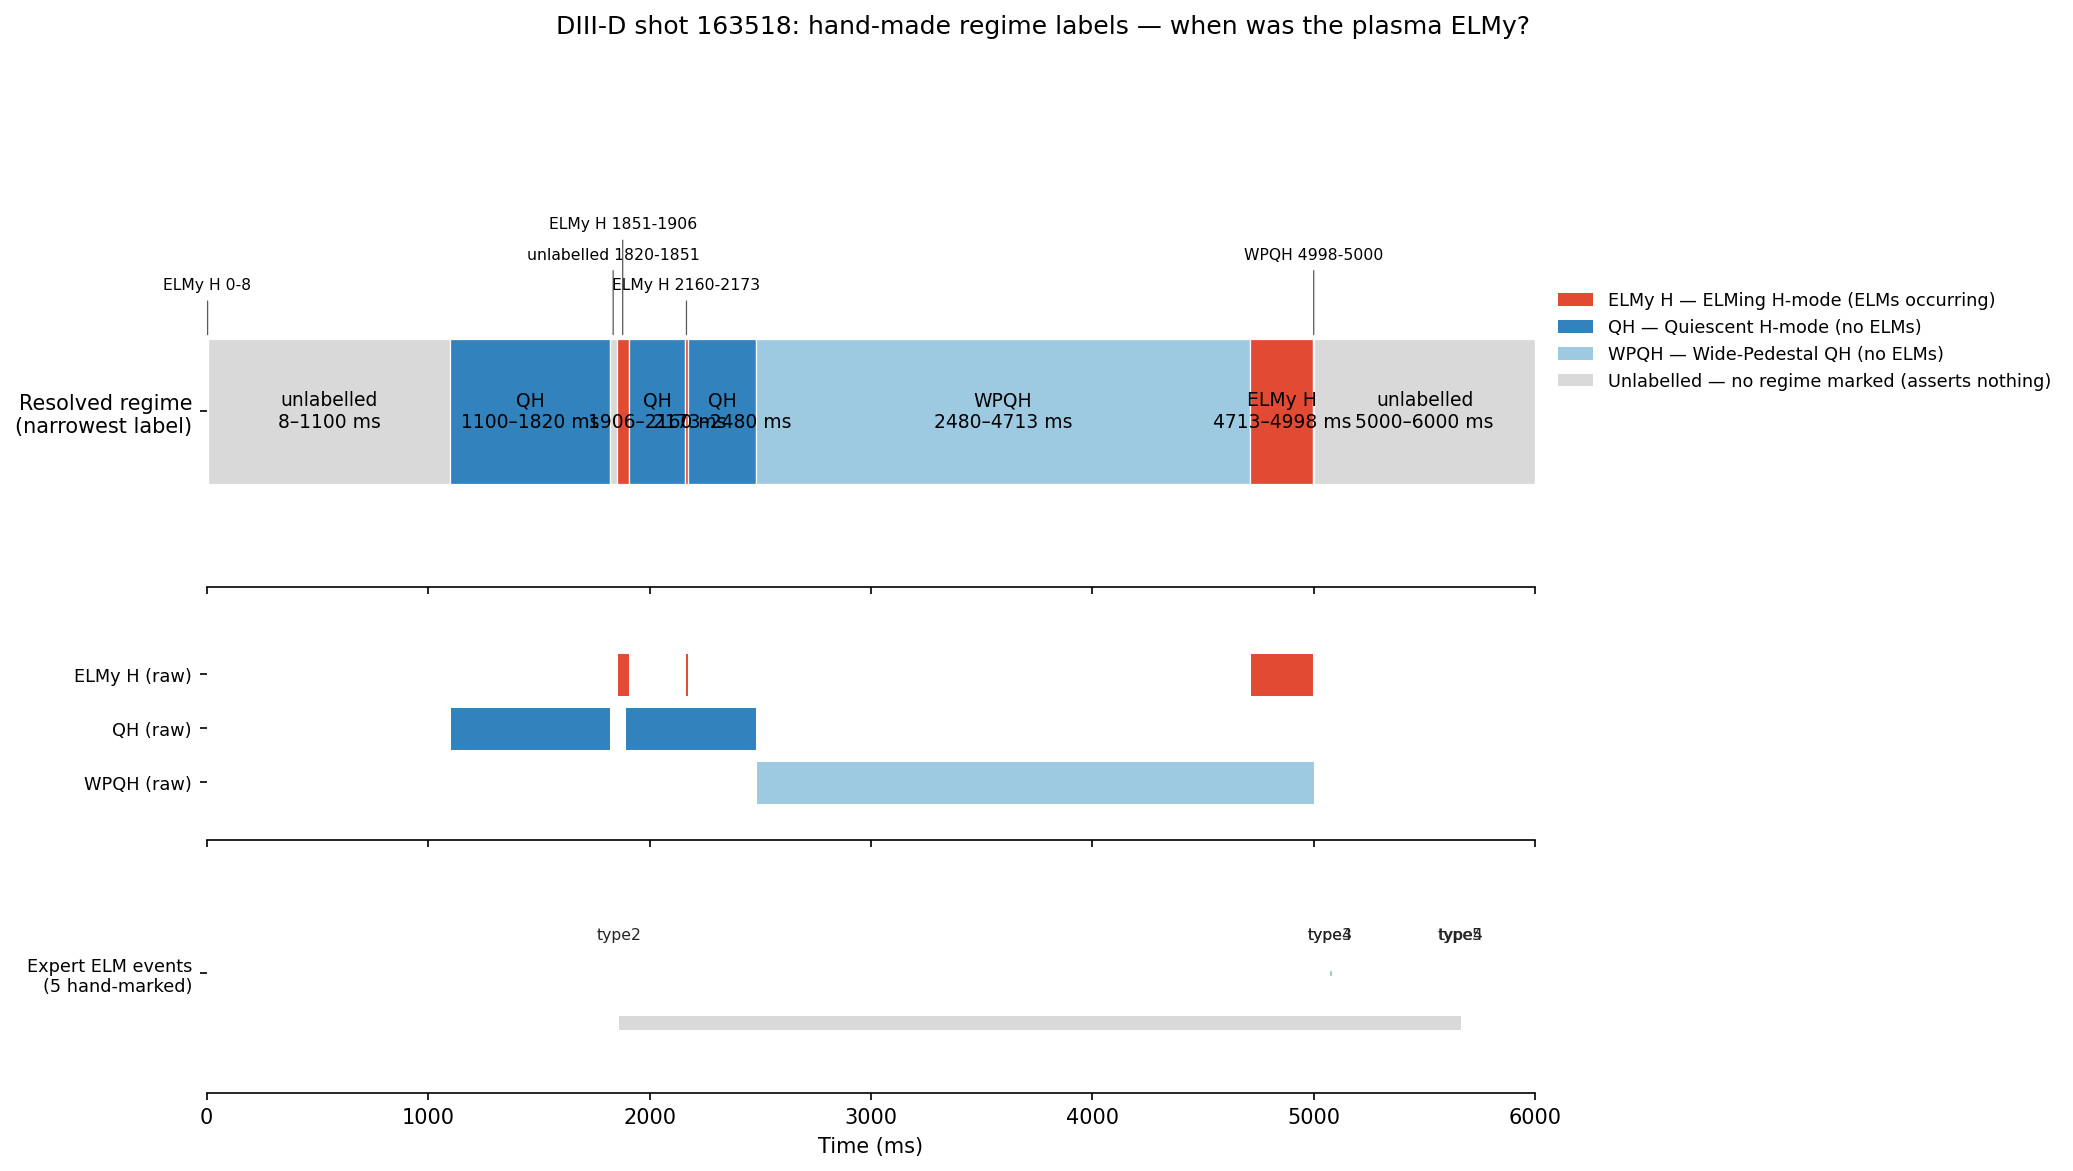

### What these labels CAN distinguish

- **ELMing vs not-ELMing** , as a statement about dominant behaviour: "ELMy H" windows assert the plasma was producing ELMs; QH and WPQH windows assert it was not.
- **Two physically different quiescent states** : QH (edge oscillates instead of ELMing) and WPQH (wide-pedestal variant) are separate classes, and the shot transitions between them at 2480 ms.
- **ELM clusters inside quiescent phases** : the expert nested narrow ELMy H windows (2160–2173, 4713–4998) inside broad quiescent spans, so "quiescent with a burst of ELMs here" is expressible and is expressed on this shot.

### What they CANNOT distinguish

- **Absent vs suppressed.** A quiescent label says no ELMs were being produced — it does not say why. No run in the stored labels marks RMP (I-coil) suppression or any other active ELM mitigation, so "naturally ELM-free" and "actively suppressed" are indistinguishable here.
- **Unlabelled time.** The 2,123 ms of gaps assert nothing — not L-mode, not quiet, not anything. The source explicitly never marked L-mode.
- **Guarantee vs assertion.** A quiescent label names the dominant behaviour the expert saw, not an impossibility proof — occasional small ELMs inside a quiescent span would still leave the span labelled quiescent unless separately marked (and the GA detector did fire 44 times inside this shot's quiescent regimes, which the expert's nesting may or may not fully account for).
- **Individual ELMs within ELMy windows.** Regime labels are intervals; the 285 ms ELMy stretch at 4713–4998 is one label, not a count. (The expert's separate event list supplies counts, but only 5 events on this shot and only within its own graded window.)
- **Where QH ends and WPQH begins, physically.** The 2480 ms boundary is the labeller's call; the labels carry no pedestal-width measurement behind it.

The "absent or suppressed" question is exactly where these labels fall short — they can say *whether* ELMs were absent, never *what suppressed them*. The one measurement that would speak to it is sitting one question away in PTDATA: I can fetch the twelve I-coil currents for this shot — measured cost on a comparable shot: **all twelve in 2.3 s, 125.7 MB decoded** — and show you when the RMP coils were energised, to check against the 1100–2480 ms QH and 2480–5000 ms WPQH spans. Shall I?

In [7]:
%%ask --review
For a DIII-D shot where an expert marked the confinement regimes, during which
time windows was the plasma ELMy and during which was ELM activity absent or
suppressed? Say which of those the labels can and cannot distinguish.

## Q4 — ELM frequency versus pedestal parameters

*ELM · science · **partial***

> **Competency question 4, as written:**
> To study ELM frequency versus pedestal parameters across a shot set, which quantities are needed, which signals provide each, and are they available on the same shots?

**Expect:** ELM frequency computed per shot, joined to the plasma parameters that
are available — and a clear statement that **pedestal quantities are not**.
Pedestal density and temperature come from profile fitting that is not in this
dataset, so this question cannot be closed without that source.

I'll plan this out, then start by re-reading the ELM-index skill and checking which other local data sources hold per-shot plasma parameters.

Skill and learnings loaded. Now reading the rest of the SKILL.md and the two skills that hold per-shot plasma parameters.

The skill docs are loaded. My plan: compute per-shot ELM frequency from the stored individual-ELM labels, join to the per-shot physics scalars in the shot-summary database, correlate, and inventory what pedestal quantities are missing. First, an exploration script to check live coverage and column availability.

The exploration shows 9,552 shots with a computable ELM frequency, 9,549 joinable to shot-summary scalars, several columns empty (L-H threshold power, ECE/CO2 peaks), and corrupt tails in some numeric columns. Now the correlation analysis with explicit quality screens and sensitivity checks.

Correlations computed — all individually weak, with the plasma-current anticorrelation strongest. One more pass: a physics-motivated composite (heating power per unit current, the standard proxy for power-over-pedestal-energy), plus the chart and a per-topology/regime check.

...

The misattribution is real: those percentiles were computed from the composite-filter list, not the full primary set. Recomputing them directly from the database over all 8,894 shots, plus the heating-complete subset separately so the two are never conflated.

Two bugs in my recompute: the frequency denominator used the sum of individual-burst durations (~5 ms each) instead of the ELMy-phase durations from the phase-level labels — inflating everything ~3.5× — and a `%`-precedence error in the last print. Fixing both and re-running.

Percentiles now internally consistent (pooled median 58.6 vs coverage-weighted topology medians 58.9). Fixing the chart script so its printed percentile line uses the full primary set rather than the composite subset.

The chart now prints the correct full-set percentiles. Recording the two lessons from this correction cycle in Learnings.md, then the final report.

## ELM frequency vs pedestal parameters: what the stored data can and cannot say

### What was computed

**ELM frequency per shot** = (number of individual-ELM labels) ÷ (total ELMy-phase duration), i.e. the rate *while ELMing*, from the GA mode_classifier detector's individual-ELM labels (default parameters, D-alpha channel chosen per shot by best SNR; numerator from the individual-ELM run, denominator from its ELMy-phase run). This is the only label set that covers enough shots for a population correlation — 9,552 shots have a computable frequency. The expert hand-marked ELM events and the OMFIT detector exist only for 23 shots, far too few for correlation, so this result is conditional on the GA detector's labels; its known over-firing during quiescent regimes is the main systematic to keep in mind.

**Quality screens applied** (results stated with them, and re-run without): exclude the 658 shots whose selected channel had negative SNR (noise exceeding signal); include SNR = +∞ (896 shots, channels with no measurable noise — a high-quality mark). Primary set: **8,894 shots** . Suspect scalar values were screened per parameter (negative plasma current, beta_N up to 3.5e5, negative stored energy, line densities to 6.7e21 m⁻³), and the shot-summary database was joined on 9,549 of the 9,552 shots.

**ELM frequency in the primary set (8,894 shots)** : min 1.8, p25 40.8, **median 58.6** , p75 79.0, p95 127.1, max 434.8 Hz — tens to low-hundreds of Hz, not kHz. (The heating-complete sub-subset with beam, ECH and flattop-current scalars all present — 4,342 shots — sits slightly higher, median 61.7 Hz, but all distribution figures above refer to the full primary set.)

### The correlations found — all weak

Rank (Spearman) correlations, primary set. Signs were stable across all sensitivity re-runs (no SNR filter; single-era 130000–139999 block), though magnitudes attenuate within one era, so treat these as index-wide, not era-specific.

| Parameter (per-shot scalar) | n | Spearman ρ |
|---|---|---|
| Plasma current, flattop (A) | 7,125 | **−0.201** |
| Mean ELM burst duration (label-internal) | 8,894 | −0.189 |
| Plasma current, max | 8,812 | −0.155 |
| Ohmic heating power | 8,322 | −0.144 |
| Major radius | 8,764 | +0.124 |
| Elongation | 8,769 | −0.115 |
| Minor radius | 8,769 | +0.097 |
| **Net heating power / plasma current (MW/MA)** | 4,338 | **+0.187** |
| Net heating power (beam+ECH+ohmic−radiated) | 5,096 | +0.088 |
| Neutral beam power | 7,927 | +0.074 |
| Beta_N (max) | 8,733 | +0.069 |
| Peak density (Thomson) | 5,688 | −0.052 |
| Toroidal field (max) | 8,877 | +0.059 |
| Stored energy (max) | 8,735 | −0.008 (p = 0.45, no relationship) |

Reading: the strongest single relationship is that **higher plasma current goes with lower ELM frequency** , and the strongest positive one is the **power-over-current composite** — the direction expected if ELM frequency tracks how hard the edge is being driven relative to its energy content. But nothing here exceeds |ρ| ≈ 0.2, i.e. no available parameter explains more than ~4–5% of the variance. (Pearson correlations are even weaker for several rows — the relationships are rank-ordered, not linear, and the distributions are heavy-tailed.) The burst-duration anticorrelation is label-internal, not an independent measurement. Diverted double-null shots run lower (median 49.5 Hz, n = 309) than single-null (59.4 Hz, n = 7,606 combined), and that spread is consistent with the pooled median (coverage-weighted mean of the topology medians: 58.9 Hz).


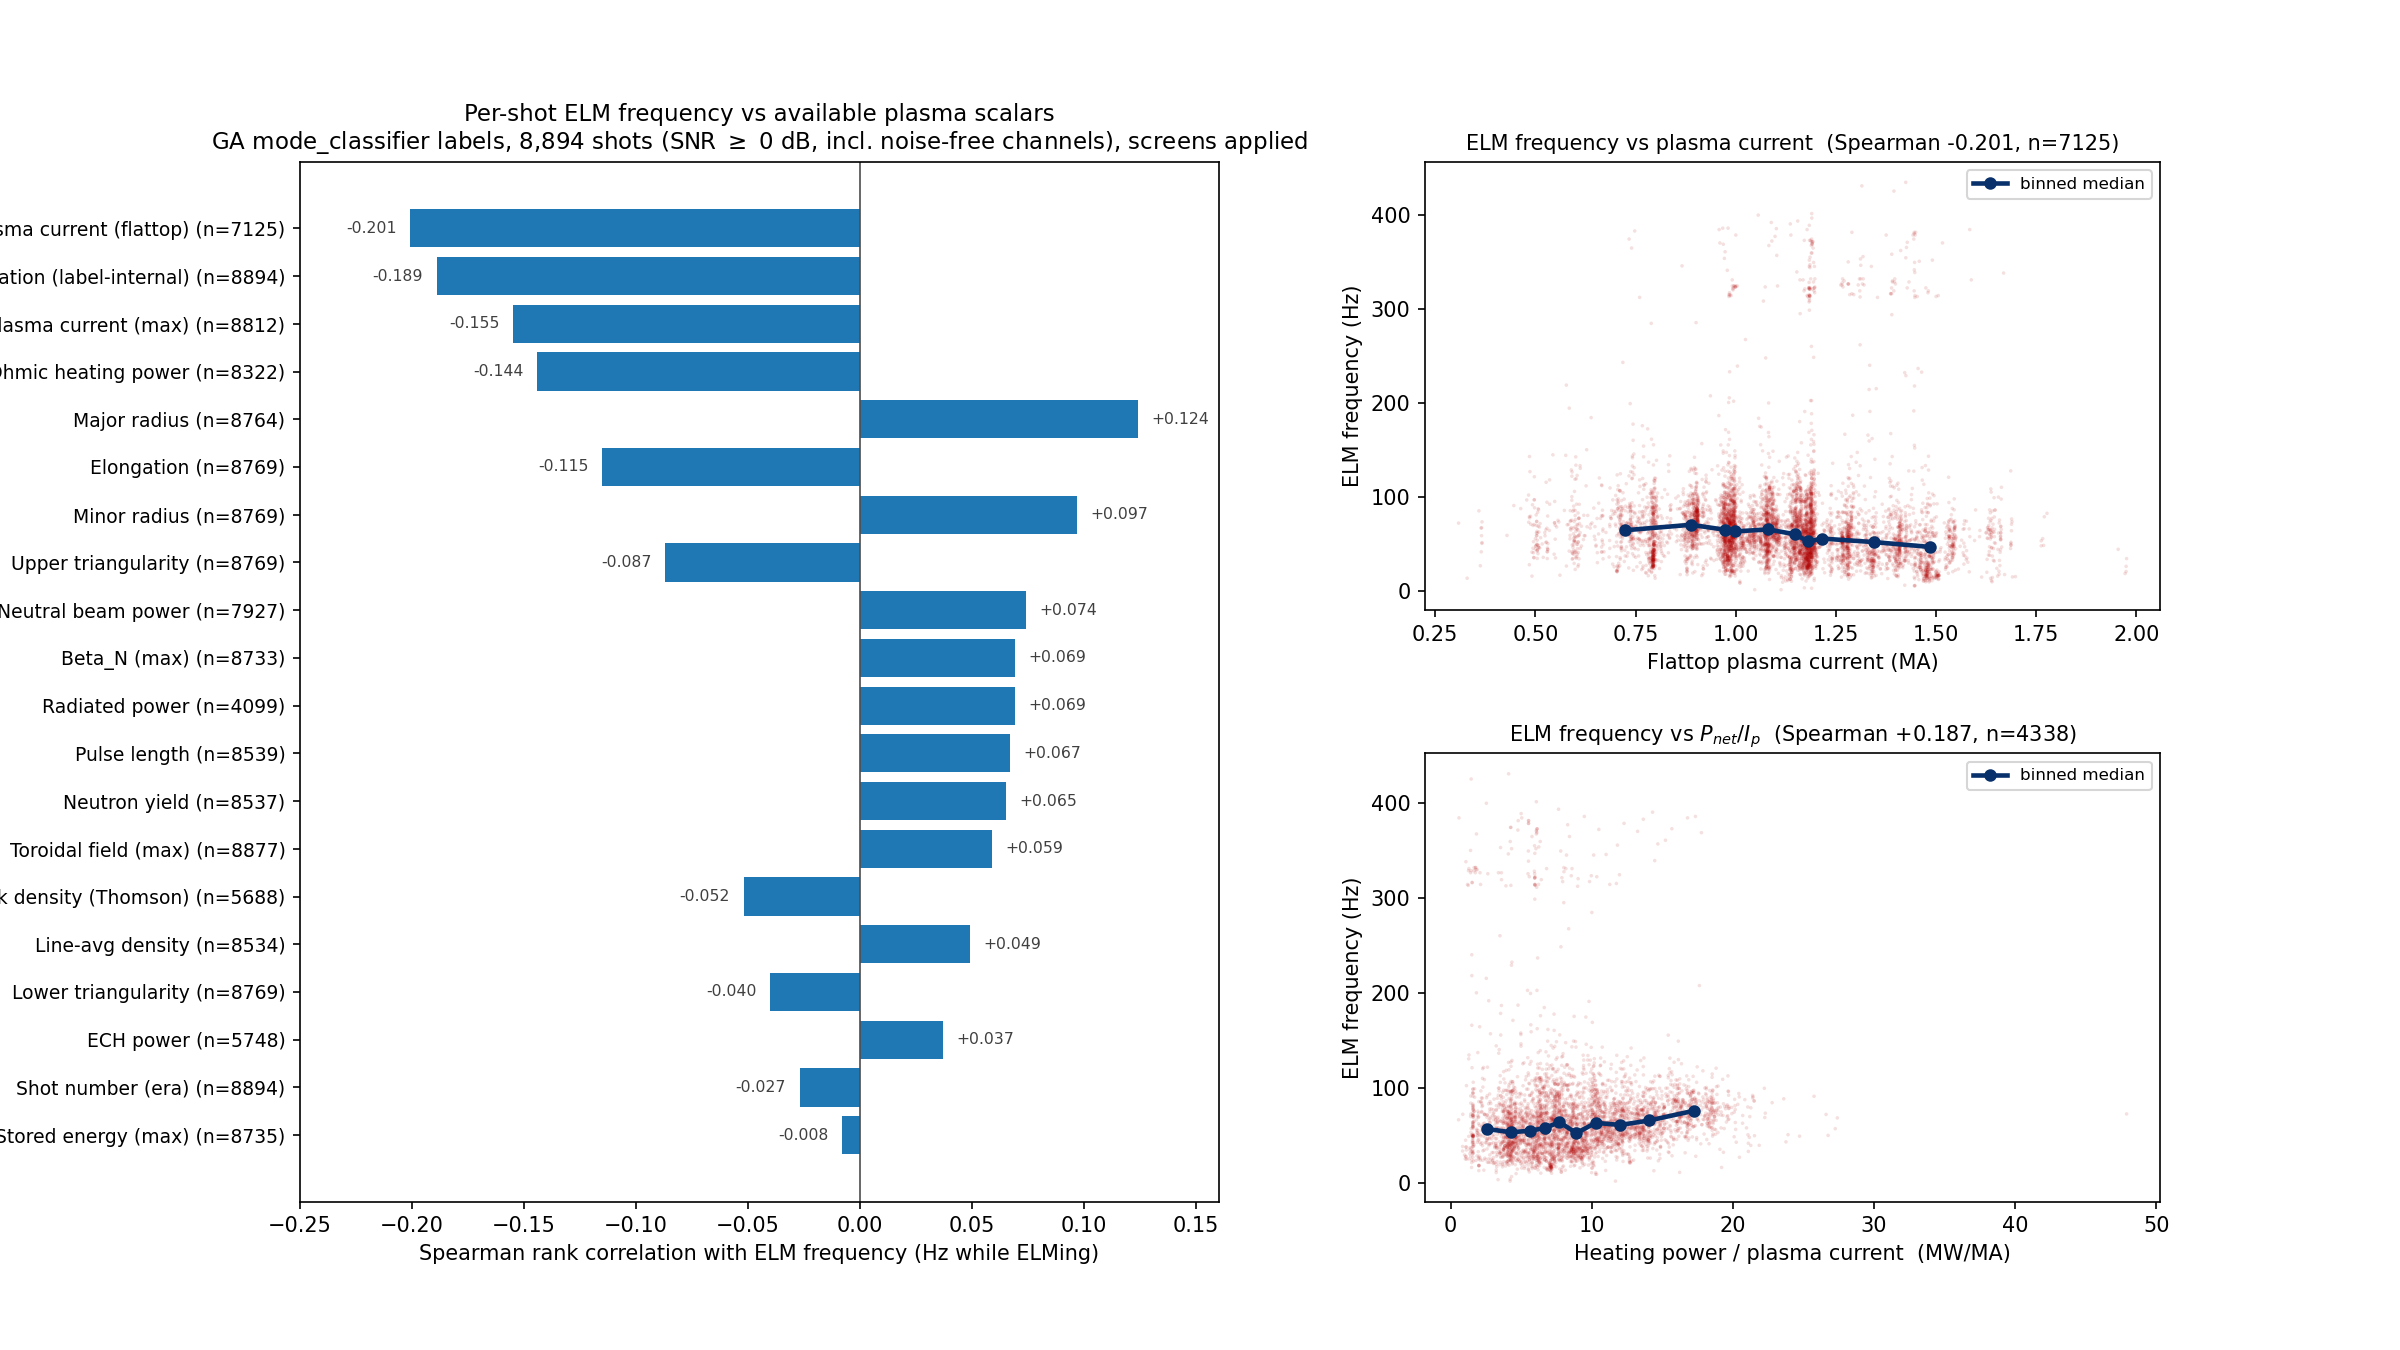

Per-shot table: `elm_freq_vs_scalars.csv` (9,552 rows: shot, frequency, burst count, ELMy duration, SNR, channel).

### What the question needs that the data does not have

The question asks about *pedestal* parameters. **None are available.** The stored per-shot scalars are machine-level and core-level quantities; everything specific to the pedestal is missing:

- **Pedestal top values and widths** — n_e,ped, T_e,ped, pedestal pressure p_ped, pedestal width Δped: no stored quantity at any granularity. The density/temperature scalars that do exist are *peak core* values (Thomson/ECE), not pedestal values.
- **Pedestal gradients and edge collisionality ν\*_ped** — not derivable without profiles.
- **q95 / edge safety factor** — not among the per-shot scalars (the disruption index carries q95 time series, but only for a 20-shot deliberately balanced slice, unusable for this population).
- **ELM energy loss ΔW_ELM and pedestal stored energy W_ped** — the quantities in the standard f_ELM ∝ P/ΔW scaling — absent.
- **Z_eff** — column exists but is empty for all rows (0 of 90,418 populated).
- **L–H threshold power P_LH** — column exists, empty.
- **RMP suppression state** — no label set marks it, and the I-coil currents are not stored; this is a plausible hidden driver of the scatter (suppressed shots sitting at low frequency).
- Degenerate or unusable despite being listed: peak T_e (ECE) and peak n_e (CO2) empty; peak T_e (Thomson) capped at 19 (57% of values at the ceiling) — excluded; days/shots-since-vent empty.

Also a structural limit: these are *one representative scalar per shot*, each taken at its own reference time, matched against a frequency averaged over the whole ELMy portion — so even for quantities that exist, this design cannot see time-resolved pedestal dynamics, only coarse shot-to-shot contrasts.

### Bottom line

With what is actually available, ELM frequency shows only weak shot-to-shot relationships — current (negative), power-per-current (positive) — consistent in sign with pedestal-physics expectations but far too weak to constitute the frequency–pedestal relationship the question is after. The parameters that scaling laws actually use (pedestal density, temperature, width, pressure, q95, ΔW_ELM, ν\*_ped) are absent from every local source; that absence, not noise, is why the correlations are weak.

Two fetches would sharpen this, and I can price them before running anything: the twelve I-coil currents per shot (measured on a comparable shot: 2.3 s and 125.7 MB for all twelve) to flag RMP-suppressed discharges and pull them out of the correlation; and q95 time series from the equilibrium reconstructions via the shot-fetcher, for the subset of shots you care about — I would measure that cost first. Shall I?

In [8]:
%%ask --review
Is there a relationship between ELM frequency and the pedestal parameters for
the shots in the ELM index? Use whatever plasma parameters are actually
available, compute ELM frequency per shot, and state clearly which quantities
the question needs that we do not have.

## Q11 — Build an ELM training dataset

*ELM · workflow · **partial***

> **Competency question 11, as written:**
> Build an ELM training dataset. Find plasma shots in a date range; narrow to shots with an H-mode period; narrow again to shots with all required filterscope pointnames archived; resolve each shot and pointname to its storage location; determine the applicable agreements and authentication; and produce a concrete fetch plan.

**Expect:** most of the chain executed as a single query — plasma shots, narrowed
to those with filterscope data, narrowed to those with ELM labels, with the
channel used for each. The links that cannot be completed should be named: an
independent H-mode filter (see Q3) and data-usage agreements as queryable
metadata.

I'll assemble this training-set candidate by chaining the ELM index's signal-availability metadata with its label sets. First, the plan and the skill docs.

Reading the rest of the skill file plus its learned-error notes.

Skill and learnings read. Now an exploration script to establish the intersection (filterscope availability × label sets) and how channel provenance is recorded per label set.

Running the exploration script to establish the intersection and provenance structure.

The run succeeded but stdout was swallowed. Writing the output to a file and reading it back instead.

...

Re-running after the rate-threshold and method-count fixes.

Numbers are now coherent — all 9,552 GA-labelled shots have a usable channel, and the union is 9,552 shots. One quick verification pass to pin down supporting facts for the report (GA status of the 77 no-D-alpha regime shots, era span, sample rows).

Verification is largely clean: the 77 excluded regime shots have **no GA run and no availability record at all** (never checked), the union spans 130882–207788, and sample rows look right. Checking what the overview figure actually plots, and confirming the 77 have zero availability rows.

Everything checks out. Before the report, recording the lessons from this task's edit-and-retry cycles in the skill's Learnings file, as required.

## Candidate ELM training set: 9,552 shots qualify

**Qualification rule applied** — a shot is in the set if (a) at least one of the five stored label sets marked it `labeled` (actual labels exist, not "ran and found nothing"), and (b) at least one D-alpha filterscope channel is present with a measured rate ≥ 9.9 kHz (the nominal 10 kHz, which measures as 9.996) and ≥ 1,000 samples. **9,552 of the 10,917 indexed shots qualify (87%)** , spanning shots 130882–207788 — i.e. the entire fast-digitizer era; nothing before 130882 qualifies because only the too-slow legacy `fs04` channel exists there.

Every qualifying shot is covered by the GA mode_classifier detector; the other three label sets are subsets of it:

| Label set | Qualifying shots | Of its total | Label-window rows written |
|---|---|---|---|
| GA mode_classifier detector — ELMy phases | 9,552 | 9,552 | 26,234 |
| GA mode_classifier detector — individual ELMs | 9,552 | 9,552 | 1,318,684 |
| Expert regime labels (hand-made) | 320 | 397 | 2,192 |
| Expert ELM events (hand-made) | 17 | 17 | 326 |
| OMFIT ELM detector | 15 | 15 | 3,637 |

Within the set: 337 shots carry ≥ 2 independent methods, 14 carry ≥ 3, and one shot (163518) has all four. The channel each GA label came from is recorded per shot — fs04da 6,746 / fs05da 1,742 / fs03da 1,064. Ten rows are honest negatives ("ran and found nothing" from the expert and OMFIT runs on shots that qualify otherwise); 658 shots' GA labels come from negative-SNR channels (noise > signal) — kept, but the manifest's SNR column flags them, and 896 have SNR = +inf (no measurable noise — a quality mark).


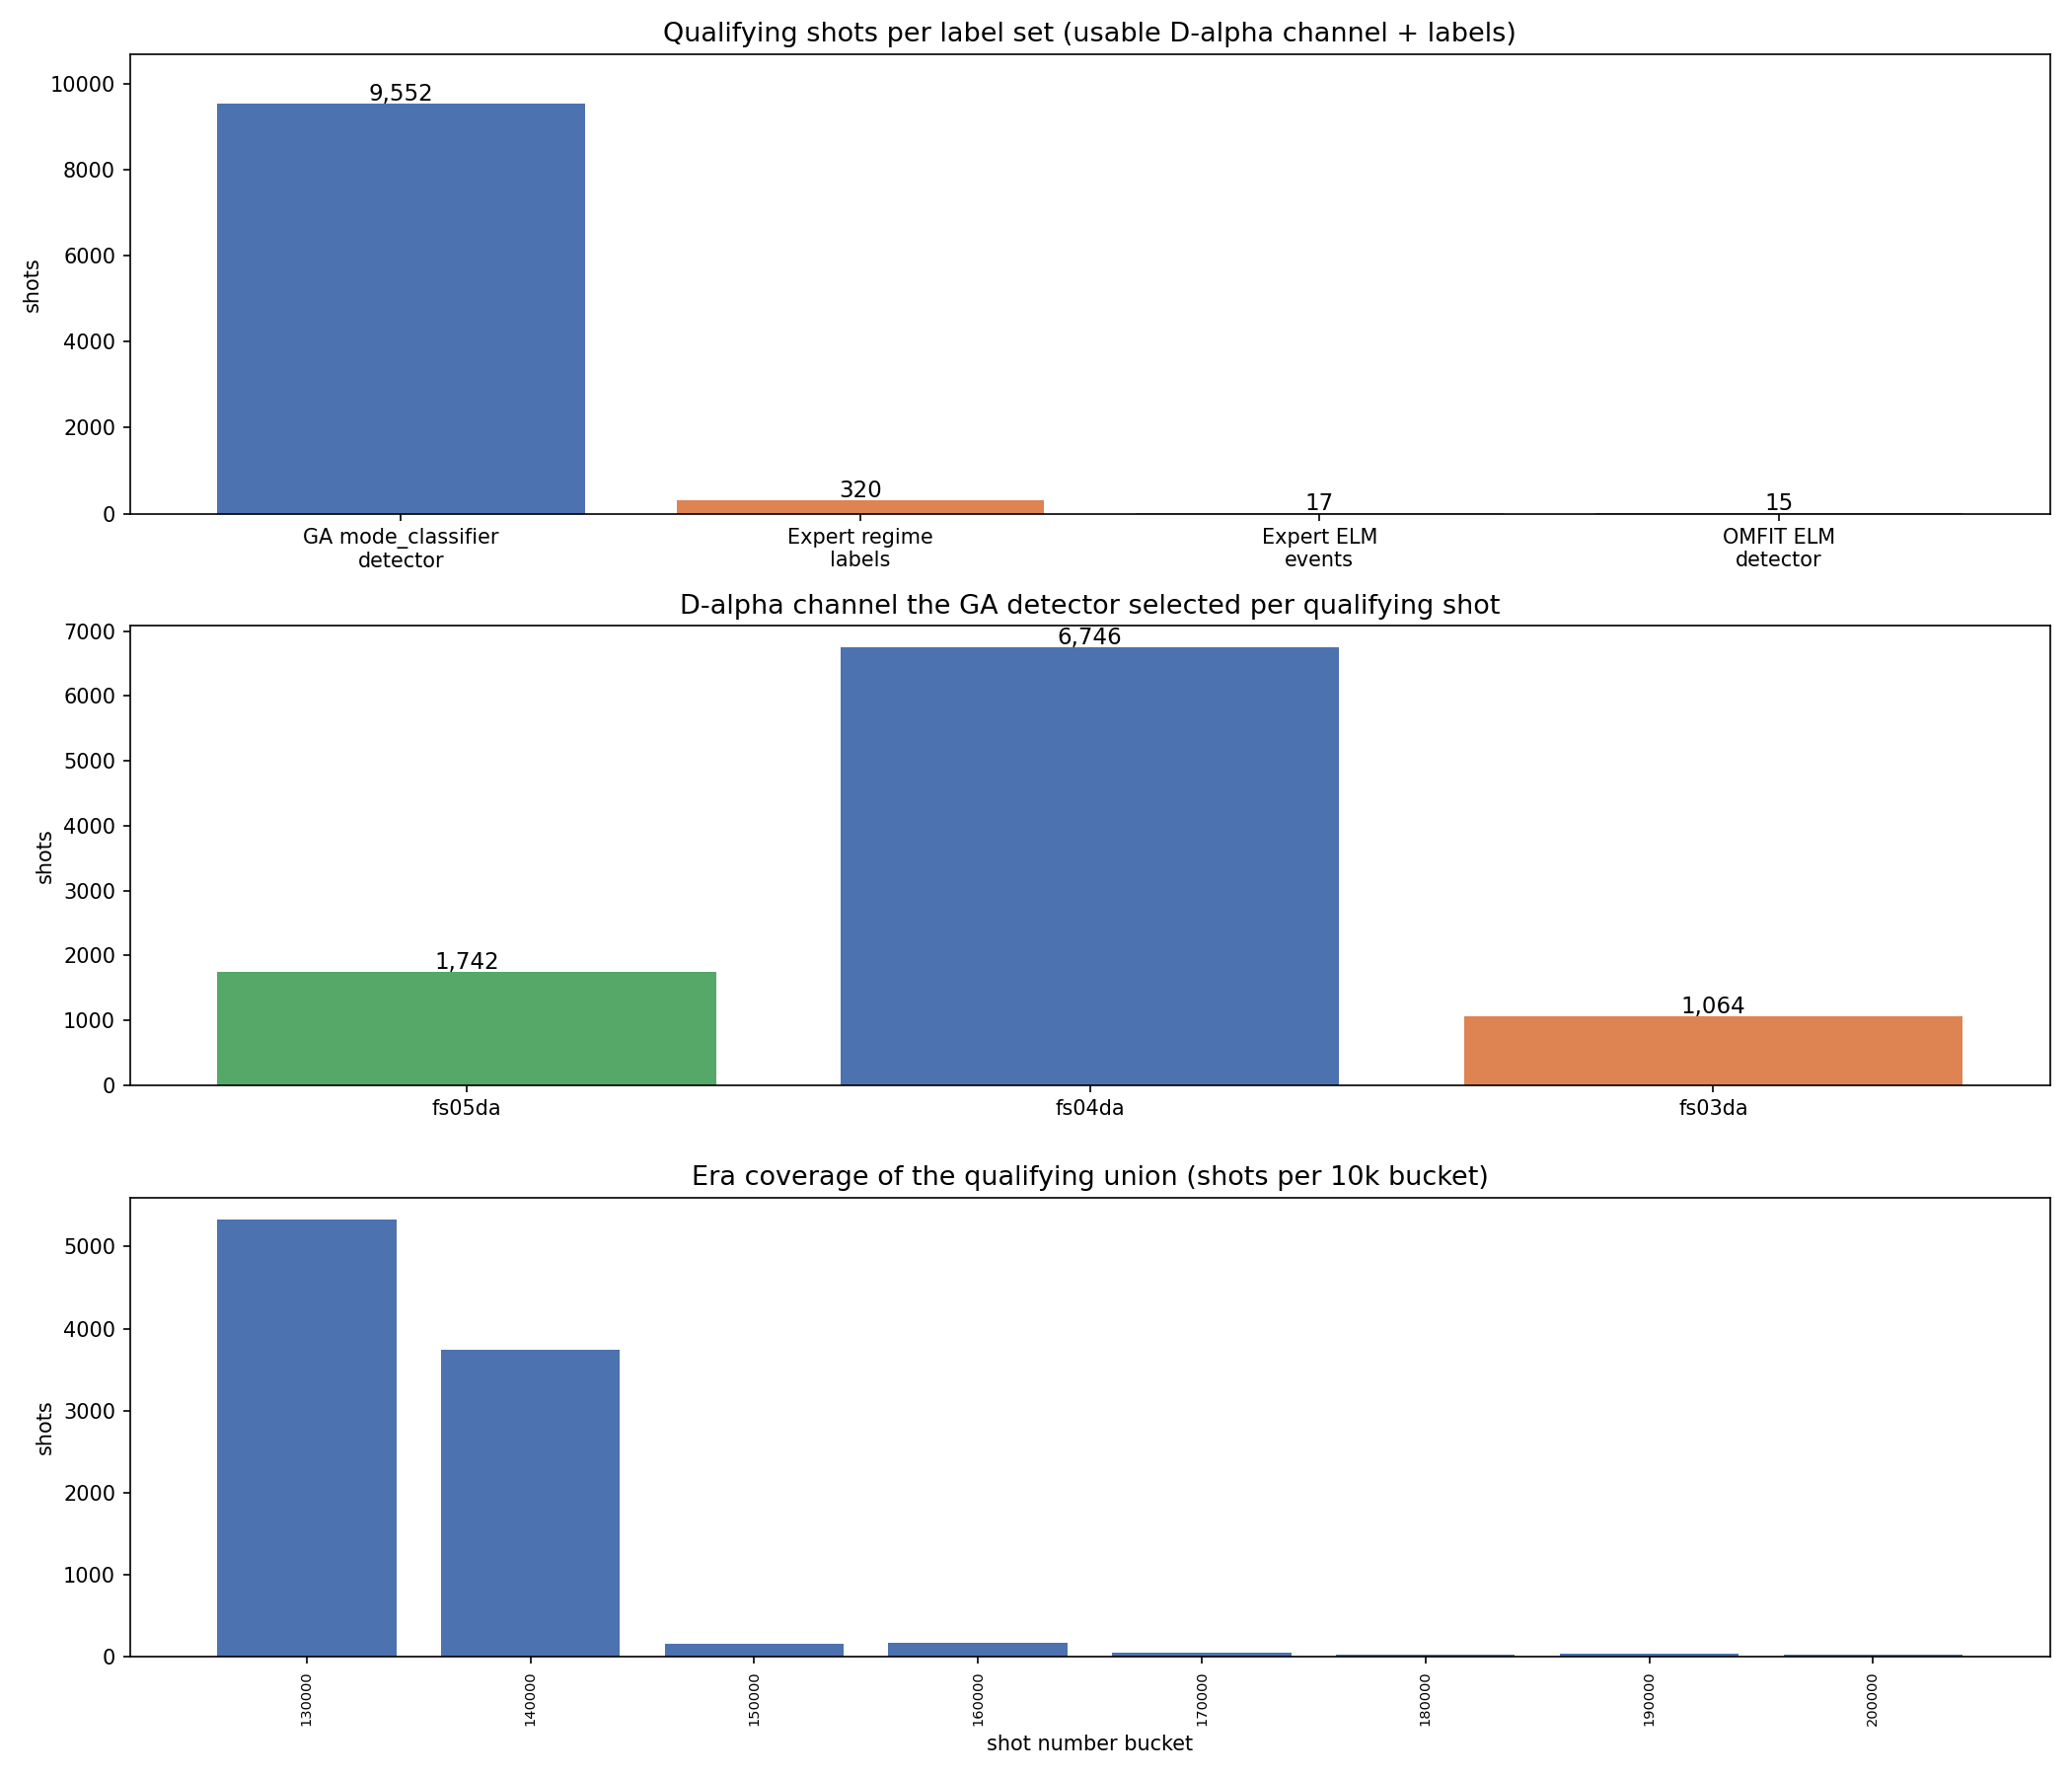

### Deliverables (in the working directory)

- **`elm_training_set_manifest.csv`** — 19,466 rows, one per (shot × label set): status, label count, analysis window, channel used, SNR
- **`elm_training_set_windows_ga_phases.csv`** / **`_ga_bursts.csv`** — every labelled window/ELM with start_ms, end_ms, duration_ms, label, channel, SNR
- **`elm_training_set_windows_expert_regime.csv`** , **`_expert_events.csv`** , **`_omfit.csv`** — same shape for the hand-made and OMFIT sets (channel column: see gaps 1–2 below)
- **`elm_training_set_shot_availability.csv`** — 38,208 rows: all four tracked channels per qualifying shot, with samples, rate, coverage, and a `usable_for_elms` verdict

### Steps of the chain I could NOT complete

1. **Channel provenance for the Expert regime labels.** That run records no signal at all — a person classified regimes; no channel is tied to the windows. The manifest column is blank for all 320 shots, honestly empty rather than back-filled.
2. **Single-channel provenance for the Expert ELM events and OMFIT sets.** Both record only a *summed chord set* (e.g. `FS00,FS05,FS06` near the strike point), not one channel — and those FS-names lie outside the four channels the availability metadata tracks, so no sampling-rate or coverage record exists for them either. The set carries the chord list verbatim.
3. **The waveforms themselves.** This is a label index, not a waveform cache: the training set pairs labels with channel metadata, but the D-alpha arrays for the 9,552 shots are not fetched. Cost measured per shot: ~31 MB crosses the wire (~9.6 MB decoded), ~1.4 s — so the full set is ~296 GB and ~3.7 h serial (~2.4 h with 8 workers).
4. **Completing archive coverage.** 10,917 shots are indexed of a much larger archive; unindexed shots were never analysed (absence ≠ no ELMs). Within the index, 856 `no_data`, 317 `error` and 119 GA `none_found` shots are excluded, and 77 Expert-regime shots are excluded because their filterscope availability was never checked at all — some would likely qualify.
5. **Window-boundary cleanup.** A few GA windows start slightly negative (e.g. −0.98 ms, from the detector's 1 ms padding); left exactly as stored and flagged here rather than silently clipped.

The natural first batch for actual training is the 23-case expert/OMFIT slice — ground truth, a second detector, and chord sets on every shot, ~713 MB and ~32 s to fetch. Want me to pull those waveforms, or a different slice?

In [9]:
%%ask --review
Assemble a candidate ELM training set: DIII-D shots that have D-alpha
filterscope data and ELM labels, with the labelled time windows and the channel
each label came from. Report how many shots qualify, and list the steps of this
chain that you could not complete with the available data.

---
# C. Questions outside the list

A system built to answer a fixed set of questions fails on the next one. None of
the four below appear in the competency-question document, and none required new
code — they are answered by combining the same stored facts.

## Does ELM behavior change during a discharge?

A physics question with no fixed template: needs individual ELM times, the
analysis window, and arithmetic over them.

I'll analyze ELM timing for shot 149058. Let me plan this first.

Reading the skill instructions and its learned-error file.

Reading the remaining lines of SKILL.md and the Learnings.md file.

Skill and learnings read. Now querying the index for shot 149058's status, ELM phases, bursts, and expert regime labels.

Running the analysis script.

...

Re-running the extended analysis script.

Reading the updated diagnostics file.

The refined analysis is complete and the figure saved. Before reporting, I'm recording the methodological lesson from this task's edit-and-retry cycle in the skill's Learnings file, per protocol.

All analysis is done — marking the plan complete before delivering the report.

## Shot 149058: ELMs became more frequent as the discharge progressed — but by ~20%, not the 5× a naive reading gives

**Computed from the GA mode_classifier detector's labels** (individual ELMs, 82 events; ELMy phases, 2 windows; channel **fs04da** , SNR 17.6 dB). This shot also has expert hand-made regime labels (7 windows), used below as a cross-check; it has no expert ELM event list and no OMFIT run, so the event-level result is conditional on that detector.

### The shot's ELM structure

Two ELMy phases: a brief start-up burst of 3 ELMs at 65–97 ms, then a **1,461 ms quiet gap** , then the main sustained ELMy phase from **1558 to 5122 ms** carrying 79 of the 82 ELMs. Overall ELM frequency 22.8 Hz (82 ELMs ÷ 3,595 ms of ELMy time), mean period 43.8 ms, mean burst length 5.4 ms.

### First third vs last third — the naive and the honest numbers

Slicing the whole first-to-last-ELM span (65–5122 ms) into clock-time thirds gives 8 → 31 → 43 ELMs, i.e. 4.8 Hz → 25.5 Hz, a 5.4× rise. **But the first third is 87% non-ELMy time** (only 224 of 1,685 ms are inside an ELMy phase — mostly the quiet gap), so that comparison measures the gap, not the plasma. Normalised to ELMy time, the first third actually fires at 35.7 Hz. The like-for-like comparisons:

| Basis | First third | Last third | Change |
|---|---|---|---|
| Main ELMy phase (1558–5122 ms), thirds of phase time | 25 ELMs, 21.1 Hz | 29 ELMs, 24.4 Hz | **+16%** |
| Equal-ELM-count thirds (26 vs 26 ELMs of the main phase) | mean period 50.4 ms (19.9 Hz) | mean period 41.5 ms (24.1 Hz) | **+21%** |

The rise is real and consistent under both definitions: the ELM period shortens from ~50 ms to ~41–43 ms across the main phase. Slicing the main phase into five parts shows where it happens: median period 52.8, 56.7, 44.0, 43.6, **33.4 ms** (19.0, 17.6, 22.7, 23.0, **30.0 Hz** ) — roughly flat-to-slower through the first 40%, then accelerating steadily to a maximum rate near the end of the ELMy phase at ~5122 ms. (A plain early-half vs late-half split, 49.2 vs 48.9 ms median, hides all of this — the mid-phase dip and late acceleration cancel.)


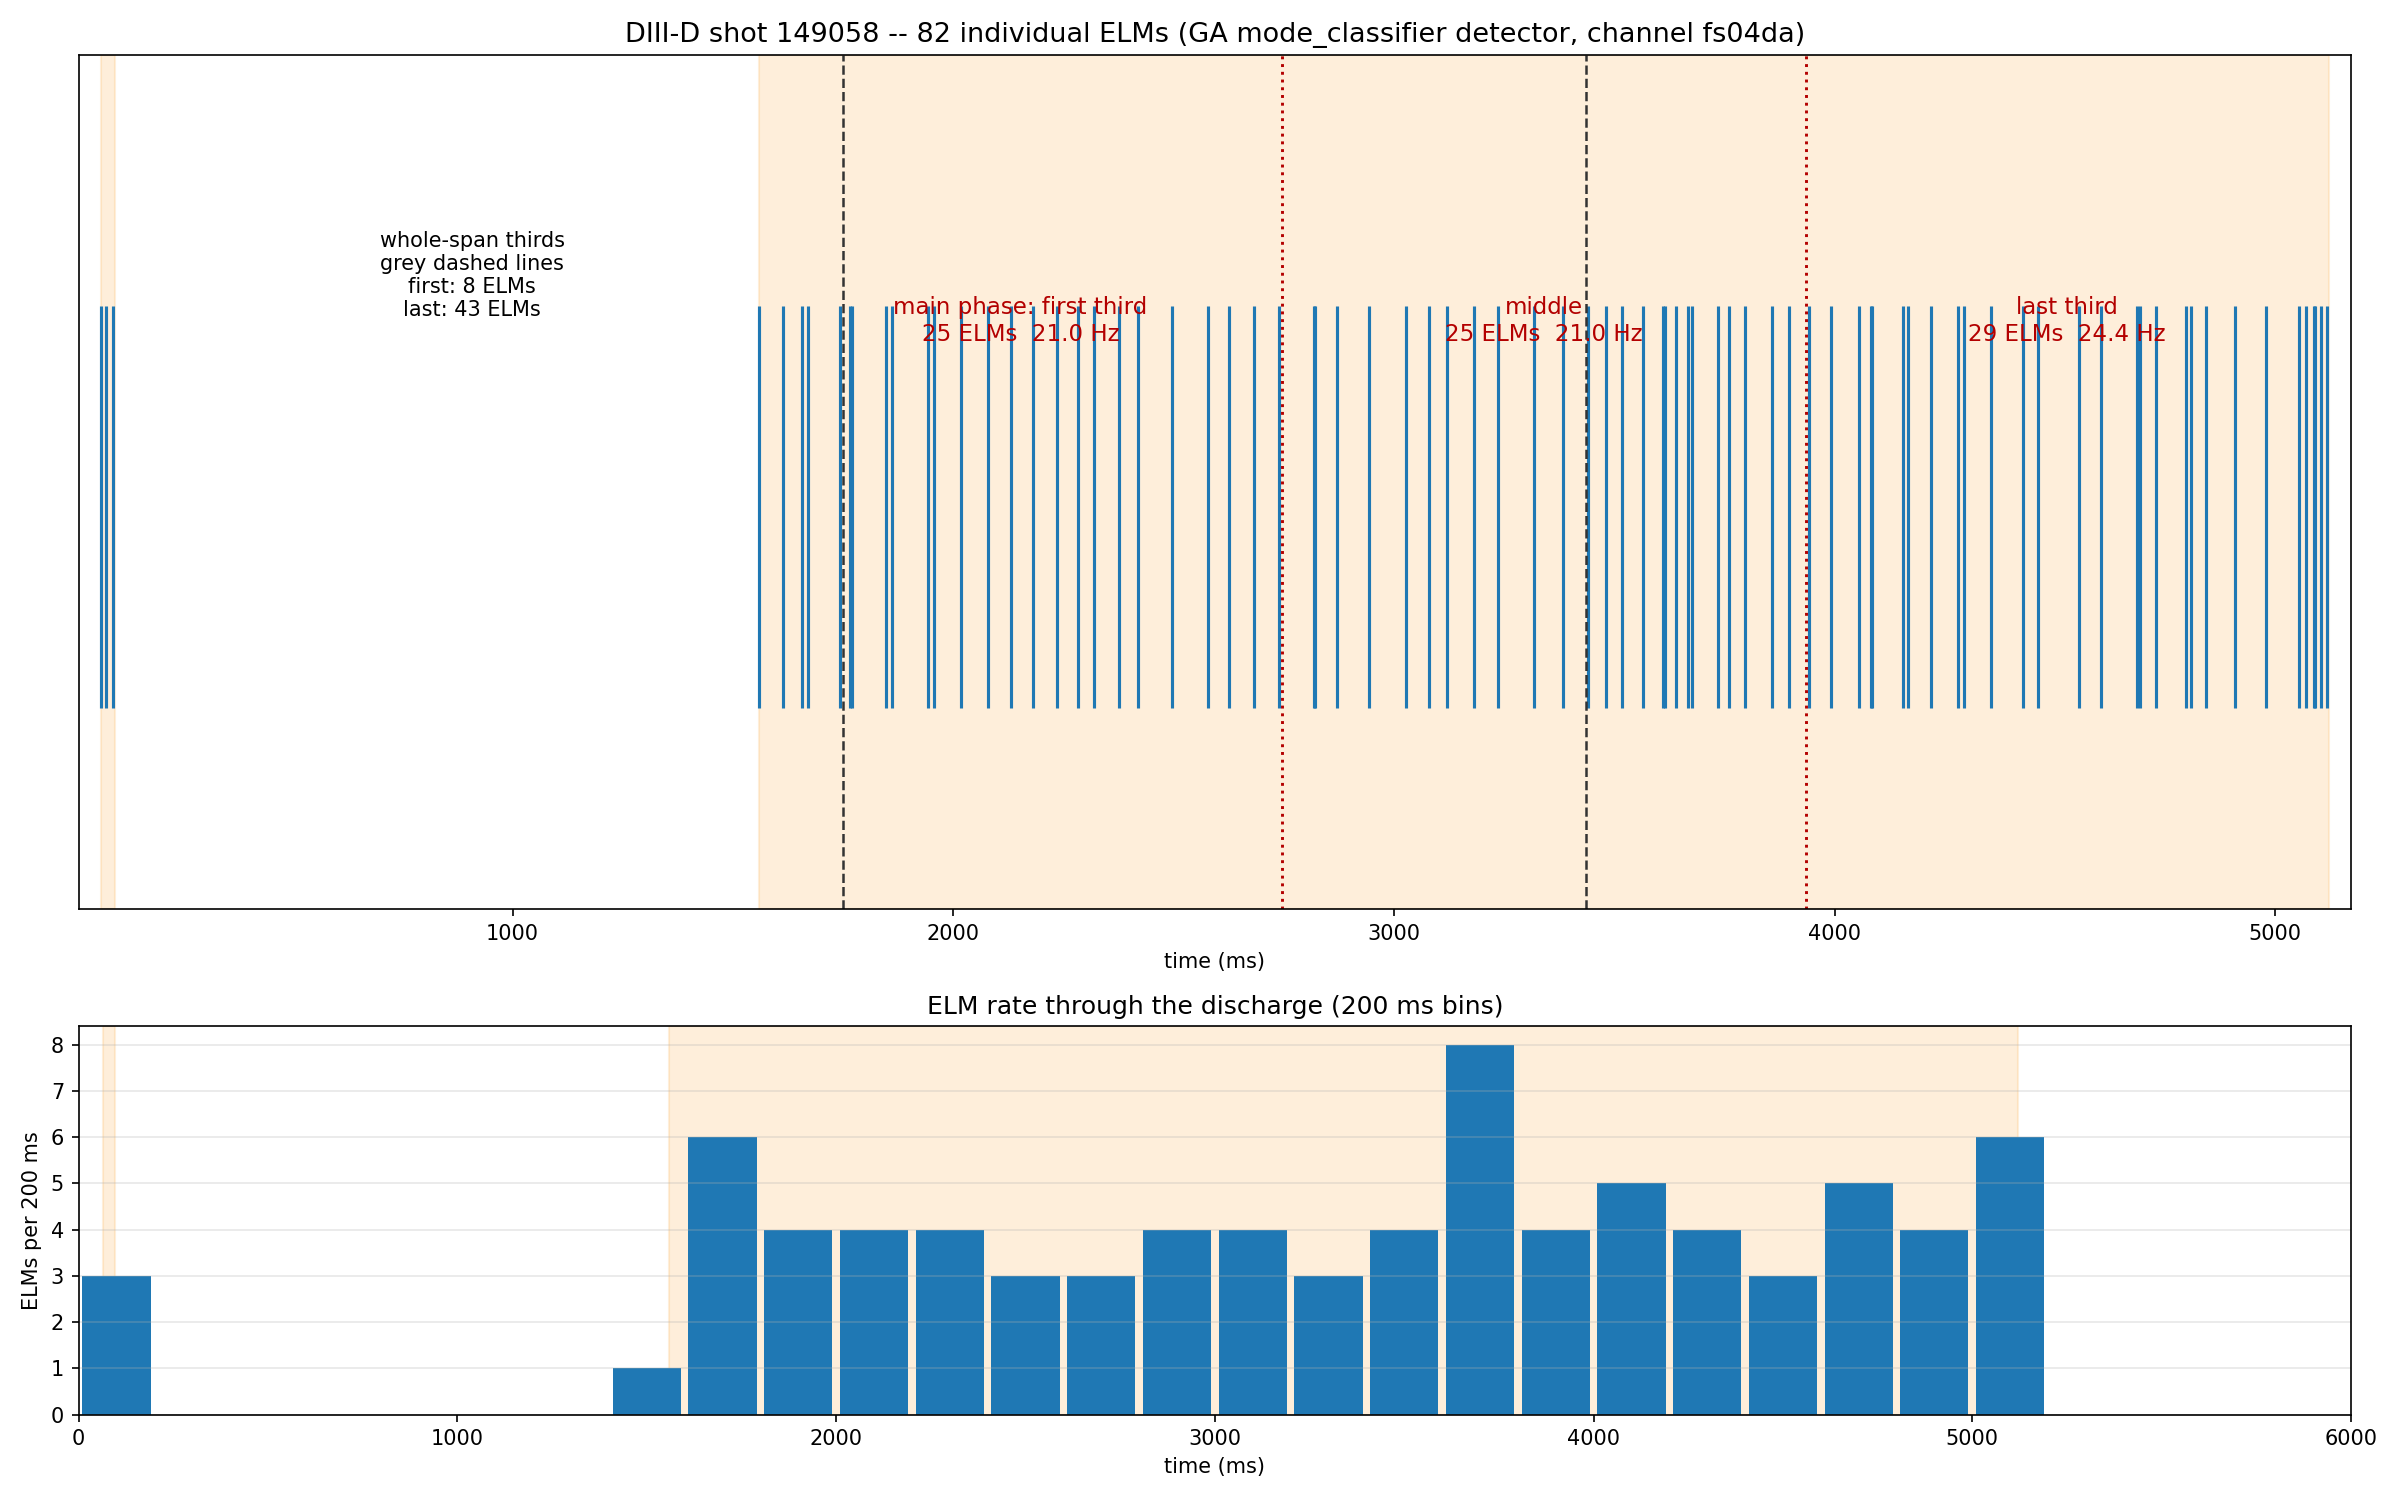

Per-ELM data behind the figure: `shot149058_elm_times.csv` (82 rows, start/end/duration per ELM).

### Cross-check against the hand-made labels

The expert regime labels tell the same story at coarser resolution: 7 separate ELMy H windows between 1558 and 4984 ms totalling 2,674 ms — 100% of the expert-labelled time is ELMy, no quiescent regime anywhere, and the expert's first window starts at 1558 ms, matching the detector's main-phase start to within 0.4 ms. The one divergence is at the end: the detector's ELMy phase runs to 5122 ms while the expert's last window stops at 4984 ms, so the final ~138 ms of detector ELMing (including the fastest slice) sits beyond what the expert marked — a scope difference, not a disagreement, since the expert labelled only part of the discharge.

**Bottom line** : more frequent as the discharge progresses — from ~19–21 Hz to ~24 Hz on like-for-like bases, with the peak rate (~30 Hz) in the final stretch — after a start-up cluster and a 1.5 s quiet interval that a naive whole-span thirds comparison inflates into an apparent 5× trend.

The labels carry no amplitude information, so if you want to know whether these ELMs were also getting *smaller* as they got more frequent (the usual pedestal-recovery pattern), I can fetch the raw D-alpha trace for this shot — measured cost ~31 MB transferred, ~1.4 s — and plot ELM size against time alongside these rates. Shall I?

In [10]:
%%ask --review
For DIII-D shot 149058, do the ELMs become more or less frequent as the
discharge progresses? Compare the first third of the ELMy period with the last
third, and plot the ELM times.

## Find shots that behave like this one

Similarity search over derived properties — the request that follows naturally
from having one interesting shot.

Reading the skill instructions and its learned pitfalls before querying.

Reading the remainder of the skill file plus its learned pitfalls.

Plan recorded. Now writing the analysis script: pull 149058's reference statistics, define similarity bands on ELM count and ELMy duration, rank matches, compute per-shot structure metrics, and produce two charts plus a CSV.

Running the similarity analysis script; output goes to a `.out` file per the learned stdout-vanishing pitfall.

The stdout vanished as the learnings predicted — reading the `.out` diagnostics file instead.

...

The full-281 scan also found the structural family numbers I need. Before reporting, I'm recording the wrong-column-extraction bug I caught in the diagnostics (it produced identical percentile lines for two different columns) into the skill's Learnings file.

All greps on that CSV returned nothing — including shots I can see in the file — so the grep itself may be failing here. Running a control pattern I know is present.

grep's line anchoring is unreliable here — using a small script to extract the structural-family rows from the CSV instead.

All analysis verified. Marking the plan complete and writing the report.

## Shots with ELM behaviour similar to 149058

**Basis** : the GA mode_classifier detector's stored labels (default parameters; D-alpha channel chosen per shot by best SNR), of the 10,917 indexed shots — a growing, non-uniform subset of the archive, not a census. 9,552 shots carry both individual-ELM and ELMy-phase labels; similarity was computed over those.

### 149058's character, as a reference

82 individual ELMs, 3,595 ms total ELMy time, overall 22.8 Hz while ELMing — plus a distinctive *structure*: a 3-ELM start-up cluster (65–97 ms), a 1,461 ms quiet gap, then one long main ELMy phase (1558–5122 ms) holding 79 of the 82 ELMs, whose rate rises ~16% from first to last third. Where that sits in the labelled population (n = 9,552): count at the 40th percentile (median 114 ELMs, p25–p75 = 44–216), ELMy duration at the 77th (median 2,267 ms, p25–p75 = 1,055–3,483).

### What "comparable" means here — and how many shots pass

Both criteria together: individual-ELM count and total ELMy duration each within ±25% of 149058 (count 62–103, duration 2,696–4,494 ms), ANDed.

| Tolerance on both axes | Qualifying shots |
|---|---|
| ±10% | 59 |
| **±25% (primary)** | **281** |
| ±50% | 1,322 |


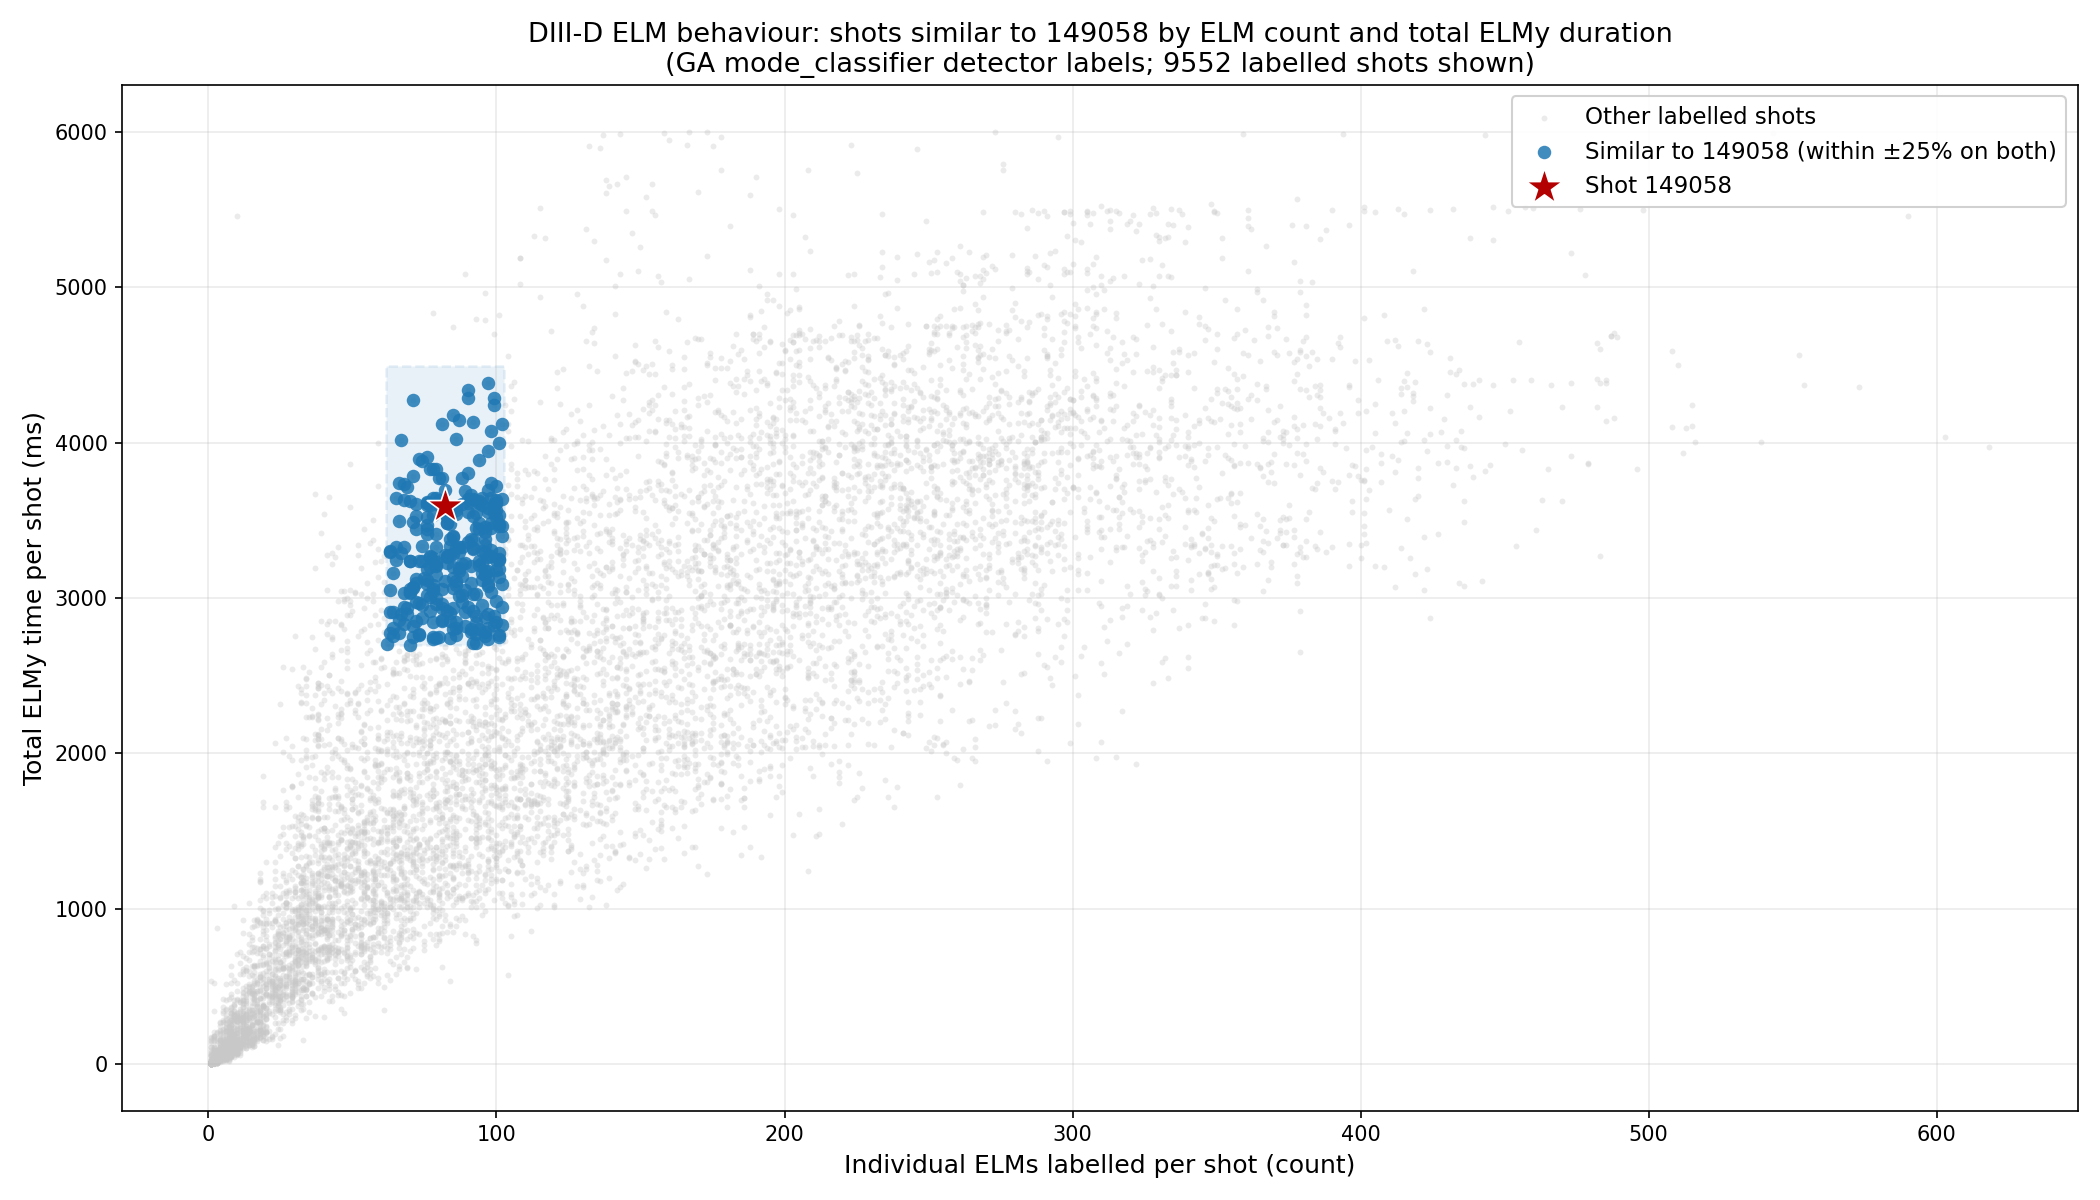

### The 15 closest matches, and how each compares

Similarity = mean fractional distance from 149058 on the two criteria (0 = identical). Every shot is within ±5 ELMs and ±6% on both quantities; the last two columns show where the behaviour *inside* the shot diverges — 149058's main phase holds 79 of its 82 ELMs and trends +16% first-to-last third.

| Shot | ELMs (Δ) | ELMy ms (Δ%) | Freq Hz (×ref) | Mean burst ms | Phases | Main phase (ms) | ELMs in main | Start-up ELMs / after | Gap ms | 1st→3rd third | Channel (SNR dB) |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 136519 | 83 (+1) | 3,528 (−2%) | 23.5 (1.03) | 5.3 | 3 | 1745–5255 | 81 | 1 / 1 | 832 | 18.8→31.6 (+68%) | fs04da 38.5 |
| 140350 | 83 (+1) | 3,519 (−2%) | 23.6 (1.03) | 6.0 | 3 | 2010–5523 | 81 | 2 / 0 | 248 | 12.8→28.2 (+120%) | fs04da 37.5 |
| 134073 | 84 (+2) | 3,525 (−2%) | 23.8 (1.04) | 3.8 | 5 | 2345–4194 | 30 | 22 / 32 | 309 | 14.6→11.4 (−22%) | fs04da 35.5 |
| 136517 | 80 (−2) | 3,596 (+0%) | 22.2 (0.98) | 6.1 | 3 | 1768–5269 | 77 | 2 / 1 | 768 | 17.1→26.6 (+55%) | fs04da 40.6 |
| 142489 | 80 (−2) | 3,627 (+1%) | 22.1 (0.97) | 4.3 | 2 | 2113–5572 | 63 | 17 / 0 | 1,398 | 10.4→29.5 (+183%) | fs04da 36.9 |
| 163463 | 82 (0) | 3,694 (+3%) | 22.2 (0.97) | 4.2 | 3 | 1186–4850 | 78 | 0 / 4 | 0 | 15.6→19.6 (+26%) | fs04da 29.5 |
| 142170 | 83 (+1) | 3,484 (−3%) | 23.8 (1.04) | 9.5 | 3 | 1429–4410 | 74 | 8 / 1 | 929 | 33.2→21.1 (−36%) | fs04da 24.2 |
| 160006 | 83 (+1) | 3,482 (−3%) | 23.8 (1.05) | 4.1 | 2 | 1660–5138 | 82 | 0 / 1 | 0 | 28.5→18.1 (−36%) | fs04da 38.0 |
| 132483 | 84 (+2) | 3,476 (−3%) | 24.2 (1.06) | 5.5 | 3 | 1478–4931 | 81 | 3 / 0 | 410 | 19.1→21.7 (+14%) | fs05da 37.8 |
| 136513 | 79 (−3) | 3,641 (+1%) | 21.7 (0.95) | 4.8 | 3 | 1635–5264 | 77 | 1 / 1 | 728 | 18.2→25.6 (+41%) | fs04da 39.0 |
| 132414 | 86 (+4) | 3,585 (−0%) | 24.0 (1.05) | 3.6 | 9 | 4316–5766 | 29 | 56 / 1 | 215 | 16.6→18.6 (+13%) | fs05da 11.8 |
| 137557 | 86 (+4) | 3,538 (−2%) | 24.3 (1.07) | 5.9 | 3 | 2546–5442 | 36 | 39 / 11 | 331 | 12.4→13.5 (+8%) | fs04da 39.8 |
| 142405 | 86 (+4) | 3,567 (−1%) | 24.1 (1.06) | 3.6 | 5 | 2503–4779 | 28 | 56 / 2 | 400 | 17.1→9.2 (−46%) | fs04da 36.0 |
| 142862 | 78 (−4) | 3,642 (+1%) | 21.4 (0.94) | 5.0 | 1 | 1391–5033 | 78 | 0 / 0 | 0 | 23.9→16.5 (−31%) | fs04da 35.4 |
| 145965 | 78 (−4) | 3,533 (−2%) | 22.1 (0.97) | 6.3 | 3 | 2174–5657 | 71 | 7 / 0 | 504 | 22.4→18.1 (−19%) | fs04da 35.5 |

Matching on the two headline numbers does not match the behaviour inside: nine of the fifteen share 149058's mild through-discharge acceleration, but five decelerate (142170, 160006, 142862, 145965, 142405), and several spread their ELMs across many phases instead of one long phase (132414: 9 phases; 134073: only 30 of 84 ELMs in its main phase).


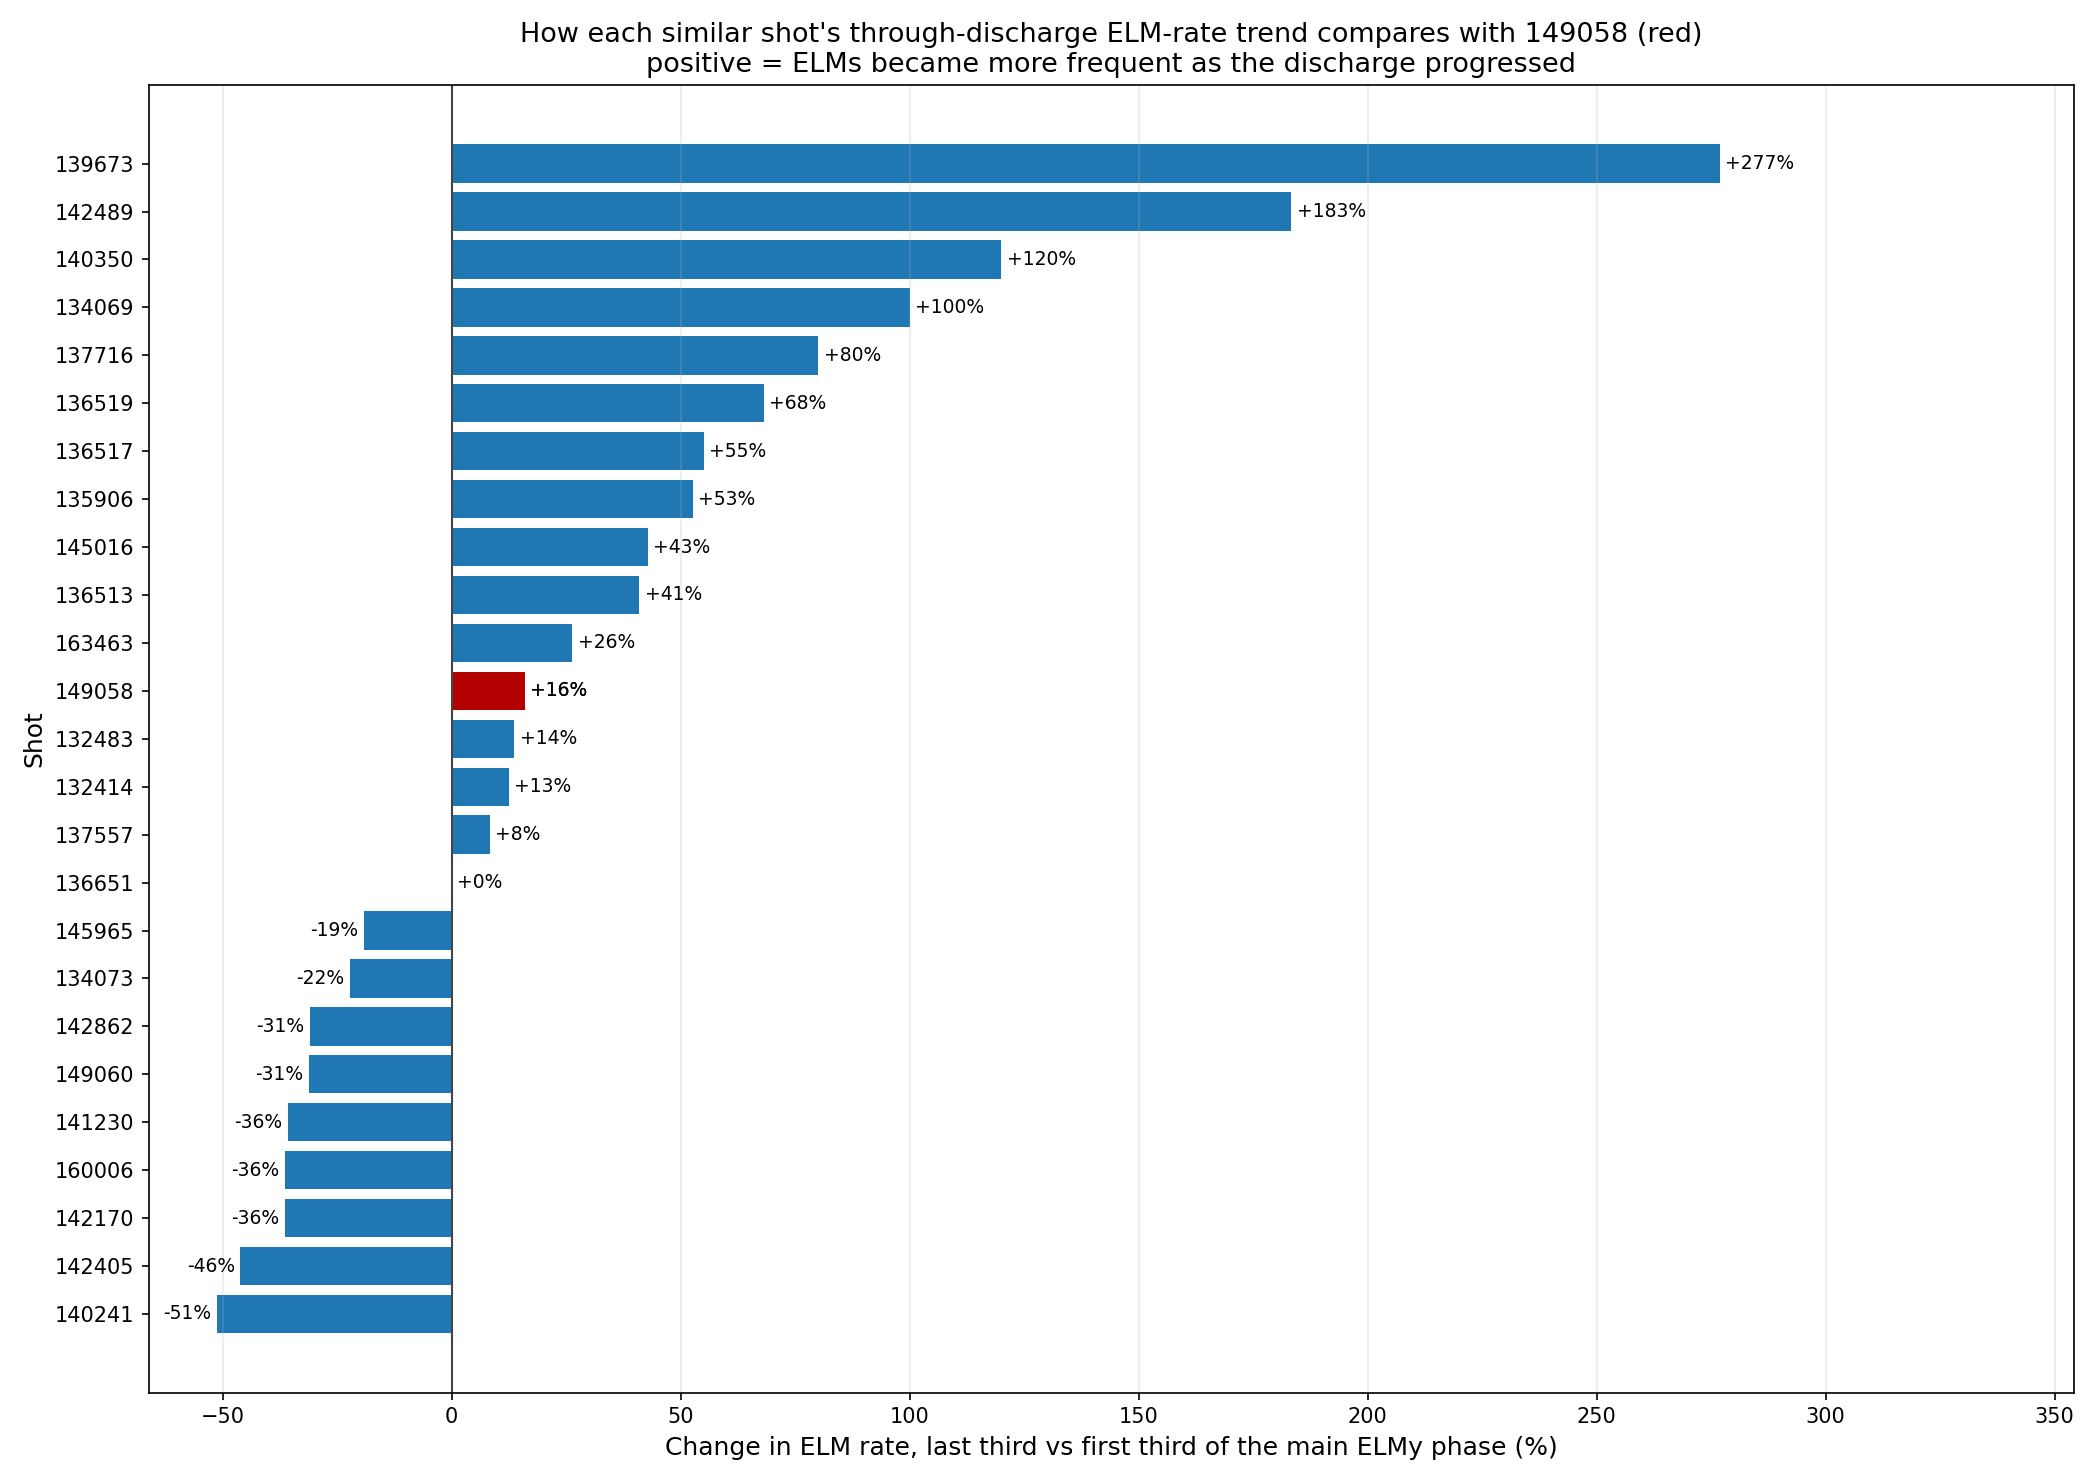

Full table for all 281 matches: `similar_shots_to_149058.csv` in the working directory.

### The shots that also share 149058's start-up-cluster-then-gap structure

Strictest test: 2+ ELMs before a ≥500 ms quiet gap ahead of the main phase. **55 of the 281** qualify. The closest by similarity score:

| Shot | Similarity | Start-up ELMs | Gap ms | Main phase ms | 1st→3rd third |
|---|---|---|---|---|---|
| 132484 | 0.46 | 2 | 1,370 | 1473–4645 | 21.8→26.5 (+22%) |
| 136284 | 0.52 | 3 | 1,424 | 1927–4834 | 14.5→48.5 (+236%) |
| 130995 | 0.54 | 6 | 2,430 | 2581–5882 | 10.9→36.3 (+233%) |
| 156662 | 0.59 | 2 | 1,189 | 1276–3302 | 17.8→14.8 (−17%) |
| 135908 | 0.59 | 2 | 1,711 | 2069–5080 | 12.0→44.8 (+275%) |
| 142491 | 0.68 | 18 | 1,401 | 2147–5141 | 10.0→54.1 (+440%) |
| 137179 | 0.75 | 7 | 1,425 | 1556–3896 | 52.6→12.8 (−76%) |

**132484 is the best structural twin** — 76 ELMs, a 2-ELM start-up cluster, a 1,370 ms gap (vs 1,461), and the same gentle +22% acceleration. The 1365xx cluster (136284, 136519, 136517, 136513) shares both the numbers and the shape, suggesting shots from one campaign day.

### What this comparison cannot see

The two similarity criteria are label-derived magnitudes; they know nothing of ELM size, pedestal state, heating or coil configuration — two shots can match on count and duration for different physical reasons. All event-level numbers rest on the GA detector's labels; the alternatives available (expert regime labels cover 149058 and 11 of the 281 matches — 163463, 160006, 149060 and others; no expert ELM event list or OMFIT run covers any of them) have not been re-run for this comparison, so treat it as conditional on that label set. One match, 141230 (SNR −5.4 dB), carries labels from a channel where noise exceeded signal; 140552 (SNR −4.2 dB) likewise in the structural family. And the index is a subset — similar discharges exist among unindexed shots too.

If you want to confirm the resemblance against the plasma itself, I can fetch the raw D-alpha traces for the top handful — 132484, 136519, 140350, 134073 — and plot their ELM trains beside 149058's, at a measured ~31 MB and ~1.4 s per shot. Shall I?

In [11]:
%%ask --review
Shot 149058 has a particular ELM character. Find other shots in the index with
similar ELM behaviour -- comparable ELM count and comparable total ELMy
duration -- and show how each compares to 149058.

## Where in the archive is there usable data?

A coverage question, and the answer contains a real finding about where
filterscope data begins and the distinct ways older shots fail.

I'll map filterscope usability across the index's full shot-number range, by decade, with failure reasons. Planning first, then reading the skill docs.

Skill and learnings loaded. Now reading the schema and availability sections of the skill file.

Continuing through the skill's availability sections.

Skill and learnings fully read. Marking the first step done and writing the decade-availability exploration script, with diagnostics to a `.out` file per the learned stdout pitfall.

Running the exploration script.

...

Rich first pass — clean taxonomy emerging (all-absent = `no_data`; present-but-unusable = detector `error`). Now the deep dive: error codes by decade, unusability reasons, channel-era structure, and the real-shot population per decade from d3drdb.

Excellent consistency: `no_data` ⇔ all channels absent, `error` ⇔ present-but-unusable, plus a third mode (fast data, SNR unusable, 13 shots). Now pinning down block structures, stub counts, unchecked-shot patterns, and fetch pricing.

All the evidence is in. Now building the chart and CSV, plus pricing completion of the unchecked archive.

All four scripts ran clean on first execution (no edit-retry cycles, so no Learnings update is due). Numbers fully reconcile: 9,684 usable + 300 present-not-usable + 856 all-absent = 10,840 checked. Completing the plan and reporting.

## Where the DIII-D ELM index actually has usable filterscope data

**Usable D-alpha data exists only from the 130000 decade onward** , and within that era the coverage is deep for 130000–143999 and only thin sampled strides afterwards. Before ~130882, every shot that was checked failed — for five different reasons, none of them "no ELMs". The index spans shots 55102–207788 (10,917 shots checked for labels, 10,840 of them also checked for channel availability); the archive holds **90,050 real plasma shots** in that range (counted from the shot database, not shot numbers), so what follows describes the **12% that has been checked** , not the archive.

"Usable" below means: at least one channel present at a measured rate ≥ 9.9 kHz with ≥ 1,000 samples — the floor for resolving individual ELMs (the detector's own requirement is a 2 kHz lowpass).

### Per-decade breakdown

| Decade | Real plasma shots | Checked | Usable | Present, not usable | No channel at all | Usable % of checked | Checked % of decade | Fastest rate (usable shots) |
|---|---|---|---|---|---|---|---|---|
| 50000 | 2,222 | 13 | 0 | 0 | 13 | 0% | 0.6% | — |
| 60000 | 6,482 | 36 | 0 | 0 | 36 | 0% | 0.6% | — |
| 70000 | 5,920 | 33 | 0 | 0 | 33 | 0% | 0.6% | — |
| 80000 | 4,949 | 27 | 0 | 0 | 27 | 0% | 0.5% | — |
| 90000 | 6,035 | 34 | 0 | 19 | 15 | 0% | 0.6% | — |
| 100000 | 6,070 | 33 | 0 | 33 | 0 | 0% | 0.5% | — |
| 110000 | 5,609 | 32 | 0 | 30 | 2 | 0% | 0.6% | — |
| 120000 | 6,148 | 34 | 0 | 30 | 4 | 0% | 0.6% | — |
| 130000 | 6,066 | 6,066 | 5,422 | 188 | 456 | 89.4% | **100%** | 100 kHz: 4,004; 50 kHz: 1,107; 10 kHz: 311 |
| 140000 | 6,491 | 4,050 | 3,789 | 0 | 261 | 93.6% | 62.4% | 50 kHz: 3,788; 100 kHz: 1 |
| 150000 | 5,874 | 164 | 162 | 0 | 2 | 98.8% | 2.8% | 50 kHz: 89; 100 kHz: 52; 20 kHz: 21 |
| 160000 | 5,838 | 165 | 165 | 0 | 0 | 100% | 2.8% | 50 kHz: 143; 20 kHz: 15; 100 kHz: 7 |
| 170000 | 6,180 | 53 | 51 | 0 | 2 | 96.2% | 0.9% | 50 kHz: 49; 100 kHz: 2 |
| 180000 | 5,271 | 32 | 28 | 0 | 4 | 87.5% | 0.6% | 50 kHz: 28 |
| 190000 | 5,857 | 36 | 36 | 0 | 0 | 100% | 0.6% | 50 kHz: 35; 100 kHz: 1 |
| 200000 | 5,038 | 32 | 31 | 0 | 1 | 96.9% | 0.6% | 50 kHz: 31 |

Totals reconcile exactly: 9,684 usable + 300 present-not-usable + 856 all-absent = 10,840 checked. "Usable" is an availability statement, not a label statement — of the 9,684, 9,552 carry ELM labels; 119 were analysed with the detector honestly finding nothing (89 in the 130000s, 30 in the 140000s), and 13 more (140077–140094) had fast data but no channel that produced a usable signal-to-noise, so the detector refused them.


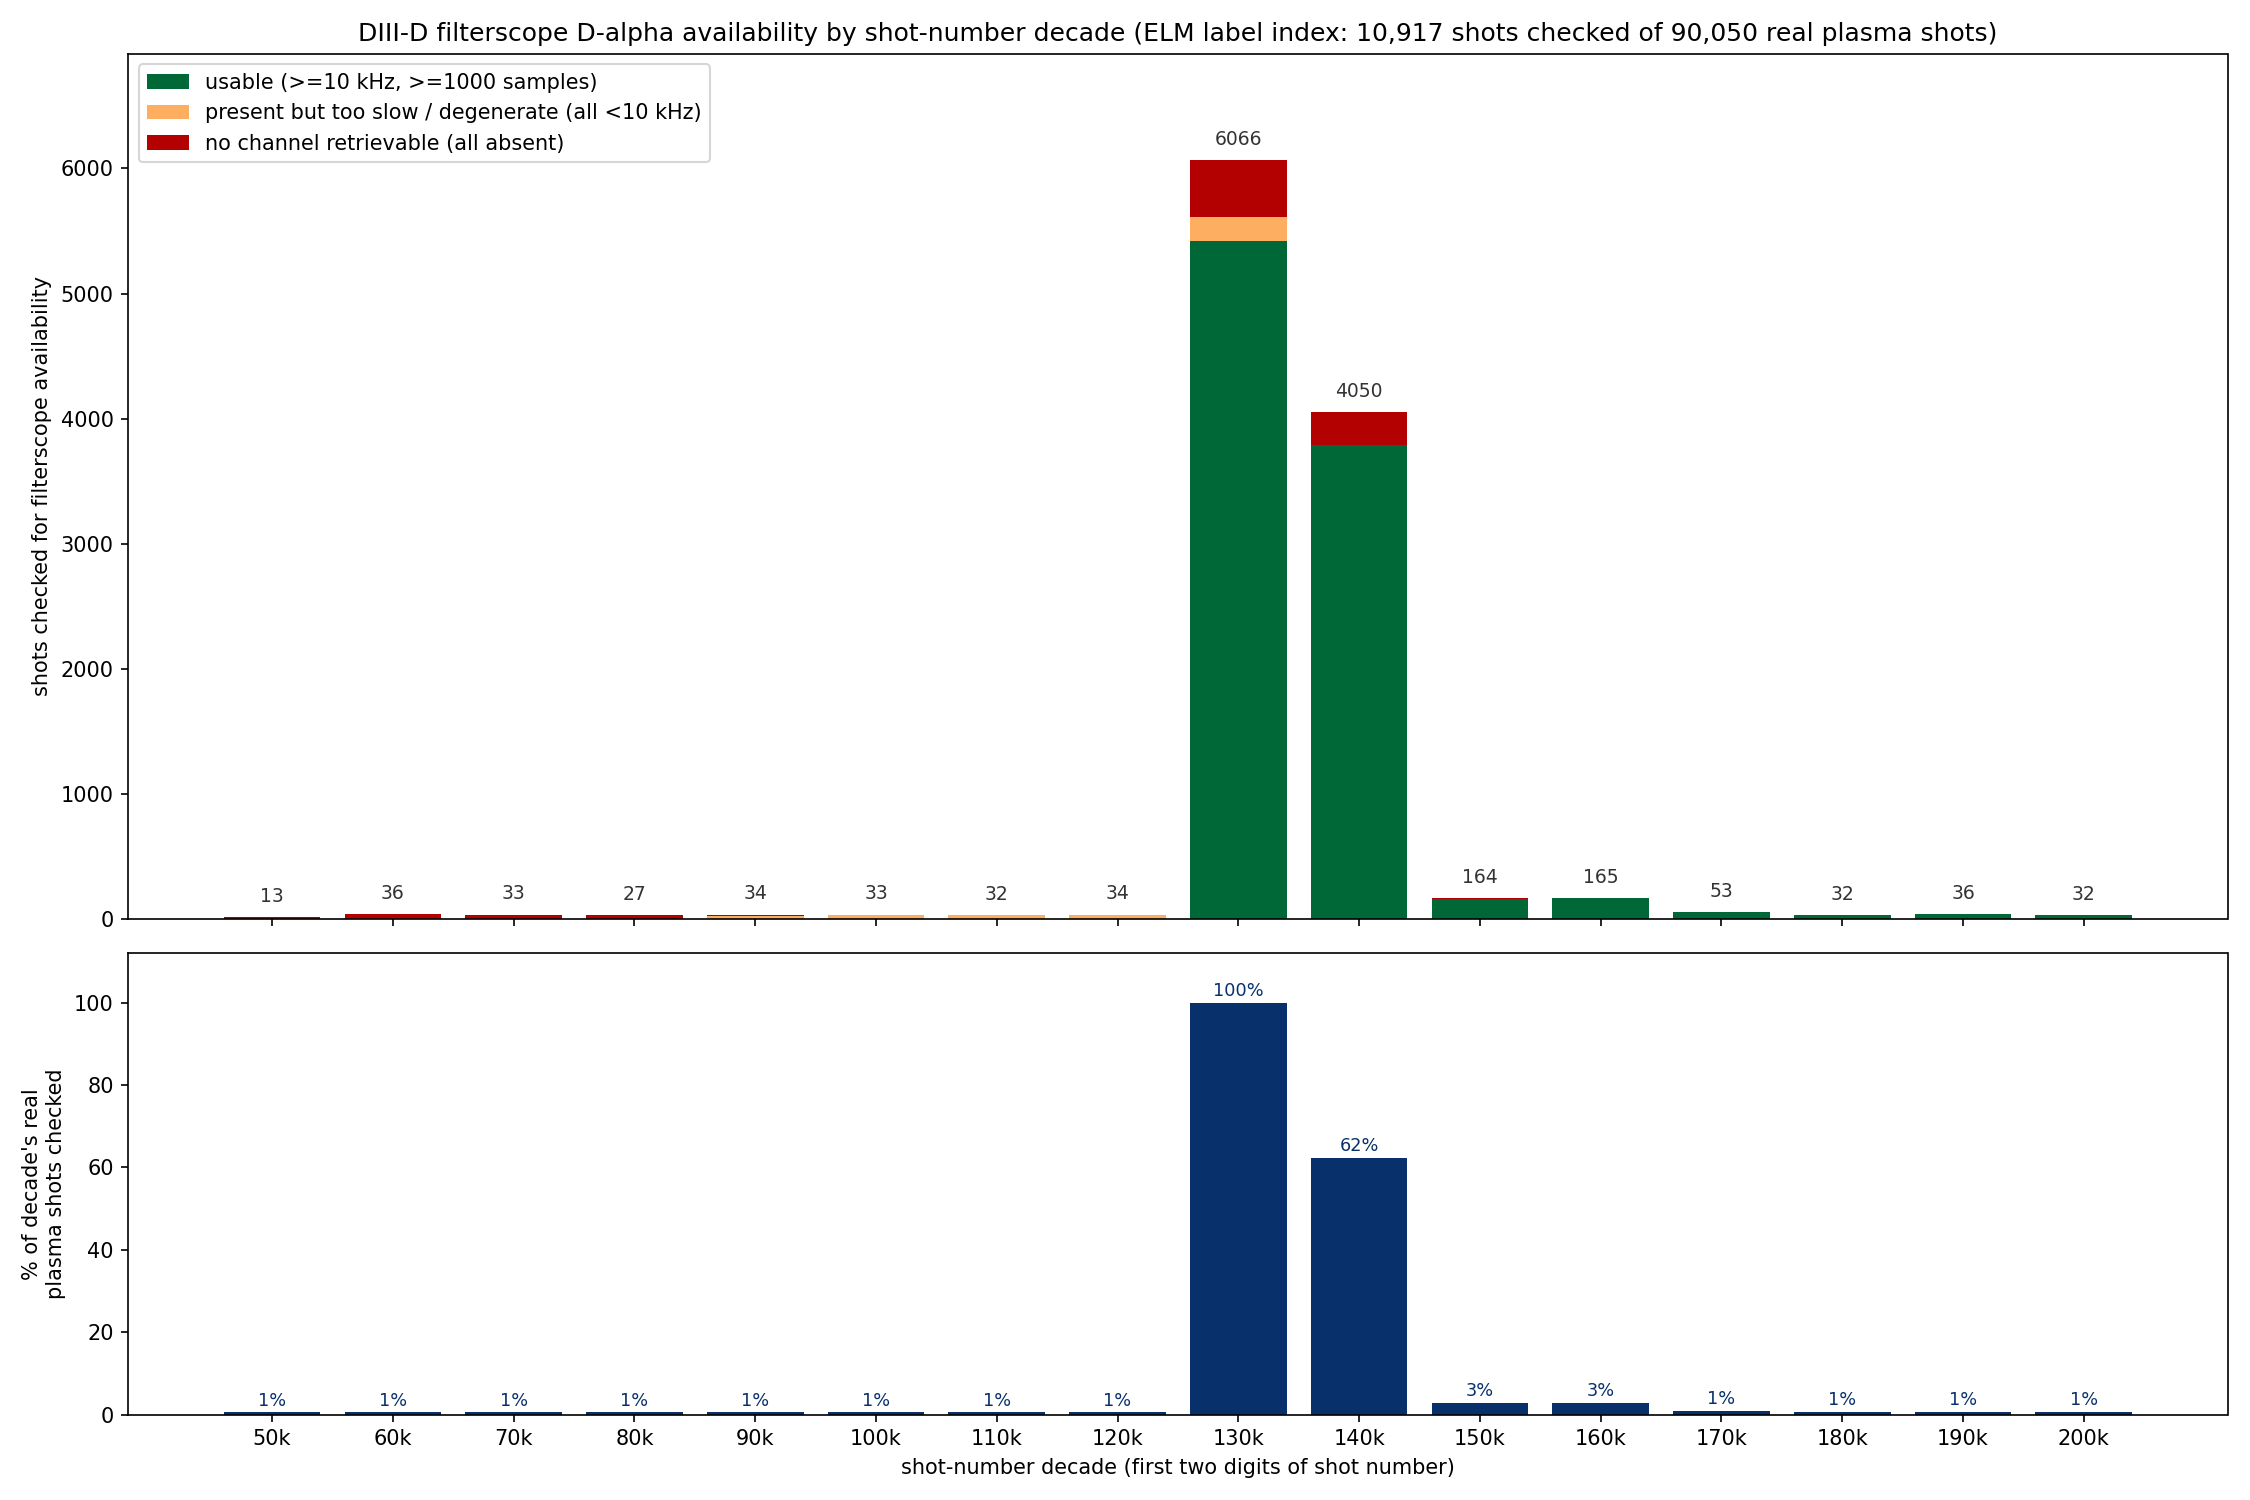

### Why shots fail — five distinct reasons, in different places

**1. Old archive format unreadable (TreeFOPENR — "file cannot be opened for read").** Dominates the 50000–80000 decades (13, 34, 31, 24 shots respectively): the MDSplus files for those discharges cannot be opened through the current access path. Also reappears as a block of 19 shots at 144299–145963 inside the otherwise-healthy 140000s, and 3 isolated shots in the 130000s.

**2. Tree opens but the node is absent (TreeNNF "node not found" / TreeNODATA "no data").** A handful in 60000–90000 (including 6 combined `TdiABORT, TreeNNF` cases), then the dominant absence mode inside the modern era: 280 TreeNODATA + 140 combined + 13 TreeNNF shots spread through the 130000s, and 242 TreeNODATA shots in the 140000s — largely contiguous blocks (e.g. 130675–132204, 139282–142928). These are shots where the filterscope channels simply were not written for that discharge.

**3. Geometry/coordinate failure (CoordinateValidationError).** Exactly 20 shots, all in the 130000s (e.g. 135270–135272) — the channel could not be resolved to a usable coordinate set.

**4. Channel present but degenerate (single sample at t = 0).** 55 shots: 19 in the 90000s (94822 onward) and a 22-shot block at 130655–131138, plus stubs elsewhere. `fs04` exists but holds one sample — present, yet meaningless.

**5. Channel present but digitized far too slowly (0.1–2 kHz).** This is the entire story of the 100000–120000 decades: every checked shot has `fs04`, but at 0.5–1 kHz (plus one 0.1, one 0.2, one 2 kHz case) — 93 shots there, plus a 166-shot block at 130000–130187. The detector's recorded reason, verbatim: *"no usable channel — fs04: sampling 0.5 kHz too low for a 2000 Hz lowpass"*. This is a property of the digitization era, not a gap: the three fast "da" channels (fs03da, fs04da, fs05da) begin only around shot 130882, and before that `fs04` is the sole channel at slow rates.

**6. Fast data present, but no usable SNR.** The 13-shot block 140077–140094: all four channels exist at 50 kHz, yet none produced a usable signal-to-noise, so the detector errored. Data present, availability "usable", still no labels.

### The coverage structure behind the table

Three different sampling strategies built this index, and the table cannot be read without them. The 50000–120000 decades were probed with a thin even stride (~30 shots per decade, ~0.6% of each decade's real shots) that established the pre-130882 boundary and then stopped — those decades are *not* fully absent, they are ~99.4% **never checked** . The 130000 and 140000 decades were checked exhaustively (100% and 62% of real shots respectively). From 150000 on, coverage returns to thin strides (~0.6–2.8%), which is why those decades show 96–100% usability on tiny denominators — the strides landed on campaign shots that mostly have data. Separately, 77 shots (149091–174659) carry expert hand-made regime labels but were never availability-checked at all — their channel status is unknown, not absent.

Per-decade table as a file: `decade_availability.csv` in the working directory.

**Caveats** : the index is a growing, non-uniform subset (absence is never evidence a shot lacks data); rates are measured (median sample spacing), which is why 50/49.951 kHz appear as near-duplicates; and "usable" says nothing about ELM labels — 658 labelled shots come from channels with negative SNR (noise > signal), which pass the rate screen.

Completing the modern era is priced from measured per-shot cost: the 35,943 never-checked shots from 130882 onward would transfer ~1.11 TB (~31 MB/shot) in ~14 h serial or ~9 h with 8 workers; the 43,193 older shots below the boundary would be cheap no-data misses (~0.65 s each, no payload) and would only confirm reason 1/2 failures. A single decade is proportionate — e.g. finishing the 140000s (2,441 shots ≈ 76 GB, ~57 min serial) or the 150000s (5,710 shots, ~176 GB, ~2.2 h serial / ~1.4 h at 8 workers). Shall I run one of those, or a slice of your choosing?

In [2]:
%%ask --review
Across the shot-number range covered by the ELM index, where do we actually
have usable filterscope data and where do we not? Break it down by shot-number
decade and explain the different reasons shots failed.

## Which results should I not trust?

Data-quality triage. The detector selects the *best available* diagnostic
channel for each shot, which is not always a *good* one.

I'll identify labelled shots whose underlying D-alpha signal quality was poor. Planning first, then consulting the skill.

The Learnings file isn't at the expected path — checking the skill directory to locate it.

The learnings live under `.sage_learnings`. Reading both remaining files.

Learnings loaded (including the SNR-trap entries and the `.out`-file stdout workaround). Now checking my previous scripts to recover the exact schema before querying.

I have all my earlier scripts. Checking the training-set builder — it has the exact join pattern between labels, runs, and signal metadata I need.

...

Stdout vanished as the learnings predict — reading the diagnostics file.

The run succeeded first try, but it surfaces something my earlier work missed: the SNR = +inf band behaves nothing like the others (median 4 ELMs vs 70–152) — that needs investigating before I report, since it determines whether those 896 shots belong on the caution list. Writing a follow-up probe.

The probe changes the picture in an important way: the SNR = +∞ band is *not* behaving like a clean high-quality cohort (median 4 ELMs vs 70–152 elsewhere, activity confined to early times), and the negative-SNR band contains the known no-plasma control shot 180445 with 543 labels — proven artefacts. Writing the final verification + CSV regeneration script.

All three scripts ran clean on first execution — no edit-retry cycles. One finding does, however, refine an existing Learnings entry (the +∞-SNR cohort is behaviourally anomalous, not simply "high-quality"), so I'm clarifying that entry before reporting.

## Labelled shots to treat with caution: 2,040 of 9,552

**Basis** : the GA mode_classifier detector's stored labels (9,552 shots carry them), and the signal-to-noise ratio it recorded for the D-alpha channel it chose on each shot. SNR is the only per-shot quality record the labels carry — no noise spectrum, no saturation flags — so "questionable" here means exactly what that number can testify to. The hand-made expert labels and the OMFIT detector record no SNR at all; how they relate to these bands is covered in the caveats.

### The bands

| Signal-quality band | Shots | Share of labelled | Median individual ELMs | Median ELMy time |
|---|---|---|---|---|
| ≥ 20 dB (good) | 7,029 | 73.6% | 152 | 2,821 ms |
| SNR = +∞ (noise estimated at zero) | 896 | 9.4% | **4** | **68 ms** |
| SNR < 0 dB (noise > signal) | **658** | 6.9% | 70 | 1,355 ms |
| 0–6 dB (signal barely above noise) | **486** | 5.1% | 70 | 1,202 ms |
| 6–20 dB (marginal) | 483 | 5.1% | 82 | 1,515 ms |

**Treat with caution: 1,144 noise-poor shots (12.0%) — the SNR < 0 dB and 0–6 dB bands — plus 896 shots in the anomalous +∞ band, 2,040 in all (21.4%).** Full per-shot list with band, channel, SNR, label count and availability: `caution_shots.csv` in the working directory.

### Why each is questionable

**SNR < 0 dB (658 shots) — the channel's noise floor exceeded its signal when the detector read it.** Whatever fired the detector was at least as likely noise as ELMs. The proof this is not theoretical: **shot 180445, a no-plasma control shot, sits here at −6.6 dB with 543 ELM labels and 5,995 ms of "ELMy" time** — those labels are artefacts by construction, and they came out of this band. 188421 (−9.3 dB, 443 labels), 131430 (−0.7 dB, 394) and 131460 (−2.3 dB, 359) are the same profile. The band is dominated by fs03da (375 shots) and fs05da (180).

**0–6 dB (486 shots) — signal and noise comparable.** Borderline detections: some fraction real, some fraction threshold-crossing noise. Mostly fs05da (381 of 486).

**The dangerous property of both noise-poor bands is that their output looks normal.** Median ELM frequency 57.2 Hz (<0 dB) and 58.2 Hz (0–6 dB) against 57.8 Hz for the good band, and 432 of the 658 negative-SNR shots land in the ordinary 40–90 Hz range with ordinary label counts (379 shots have 21–100 ELMs). Nothing about these labels flags themselves — they must be screened by SNR, not by eyeballing the counts.

**SNR = +∞ (896 shots) — not noise-poor, but not a clean bill of health either.** The detector's noise estimate came back zero, so SNR was undefined, and the labels this produced are a different kind of weak: median **4 ELMs and 68 ms of ELMy time** (vs 152 / 2,821 ms for good channels), 504 of the 896 shots have ≤5 ELMs, 227 have under 10 ms of ELMy time, and the detections cluster early — median last ELMy phase ends at 885 ms into the discharge. 884 of the 896 ran on fs04da. This looks like a cohort of short-pulse or low-activity discharges where a brief early flash (breakdown, start-up) dominates a nearly-flat record. Their *few-label* claims are fragile; if you filter a population by "has ELM labels", these 896 pass while carrying almost nothing.

**One rate anomaly** : shot 131672 has all four channels at a measured 82.96 kHz — no nominal family (50/100 kHz) — and SNR −2.5 dB, so it is already on the caution list, but its timing is non-standard too.

### Where the caution shots sit

Concentrated in the two exhaustively-sampled decades: the 130000s (328 + 421 noise-poor of 5,333 labelled) and 140000s (309 + 60 of 3,746). The late, thinly-sampled decades have small counts but high rates (180000s: 6 of 28 = 21%; 190000s: 7 of 36 = 19%). For reference, the finite-SNR distribution over all labelled shots is tight and healthy — p5 = −2.3 dB, median 35.9 dB, p95 = 42.1 dB — so the caution set is the tail, not the bulk.


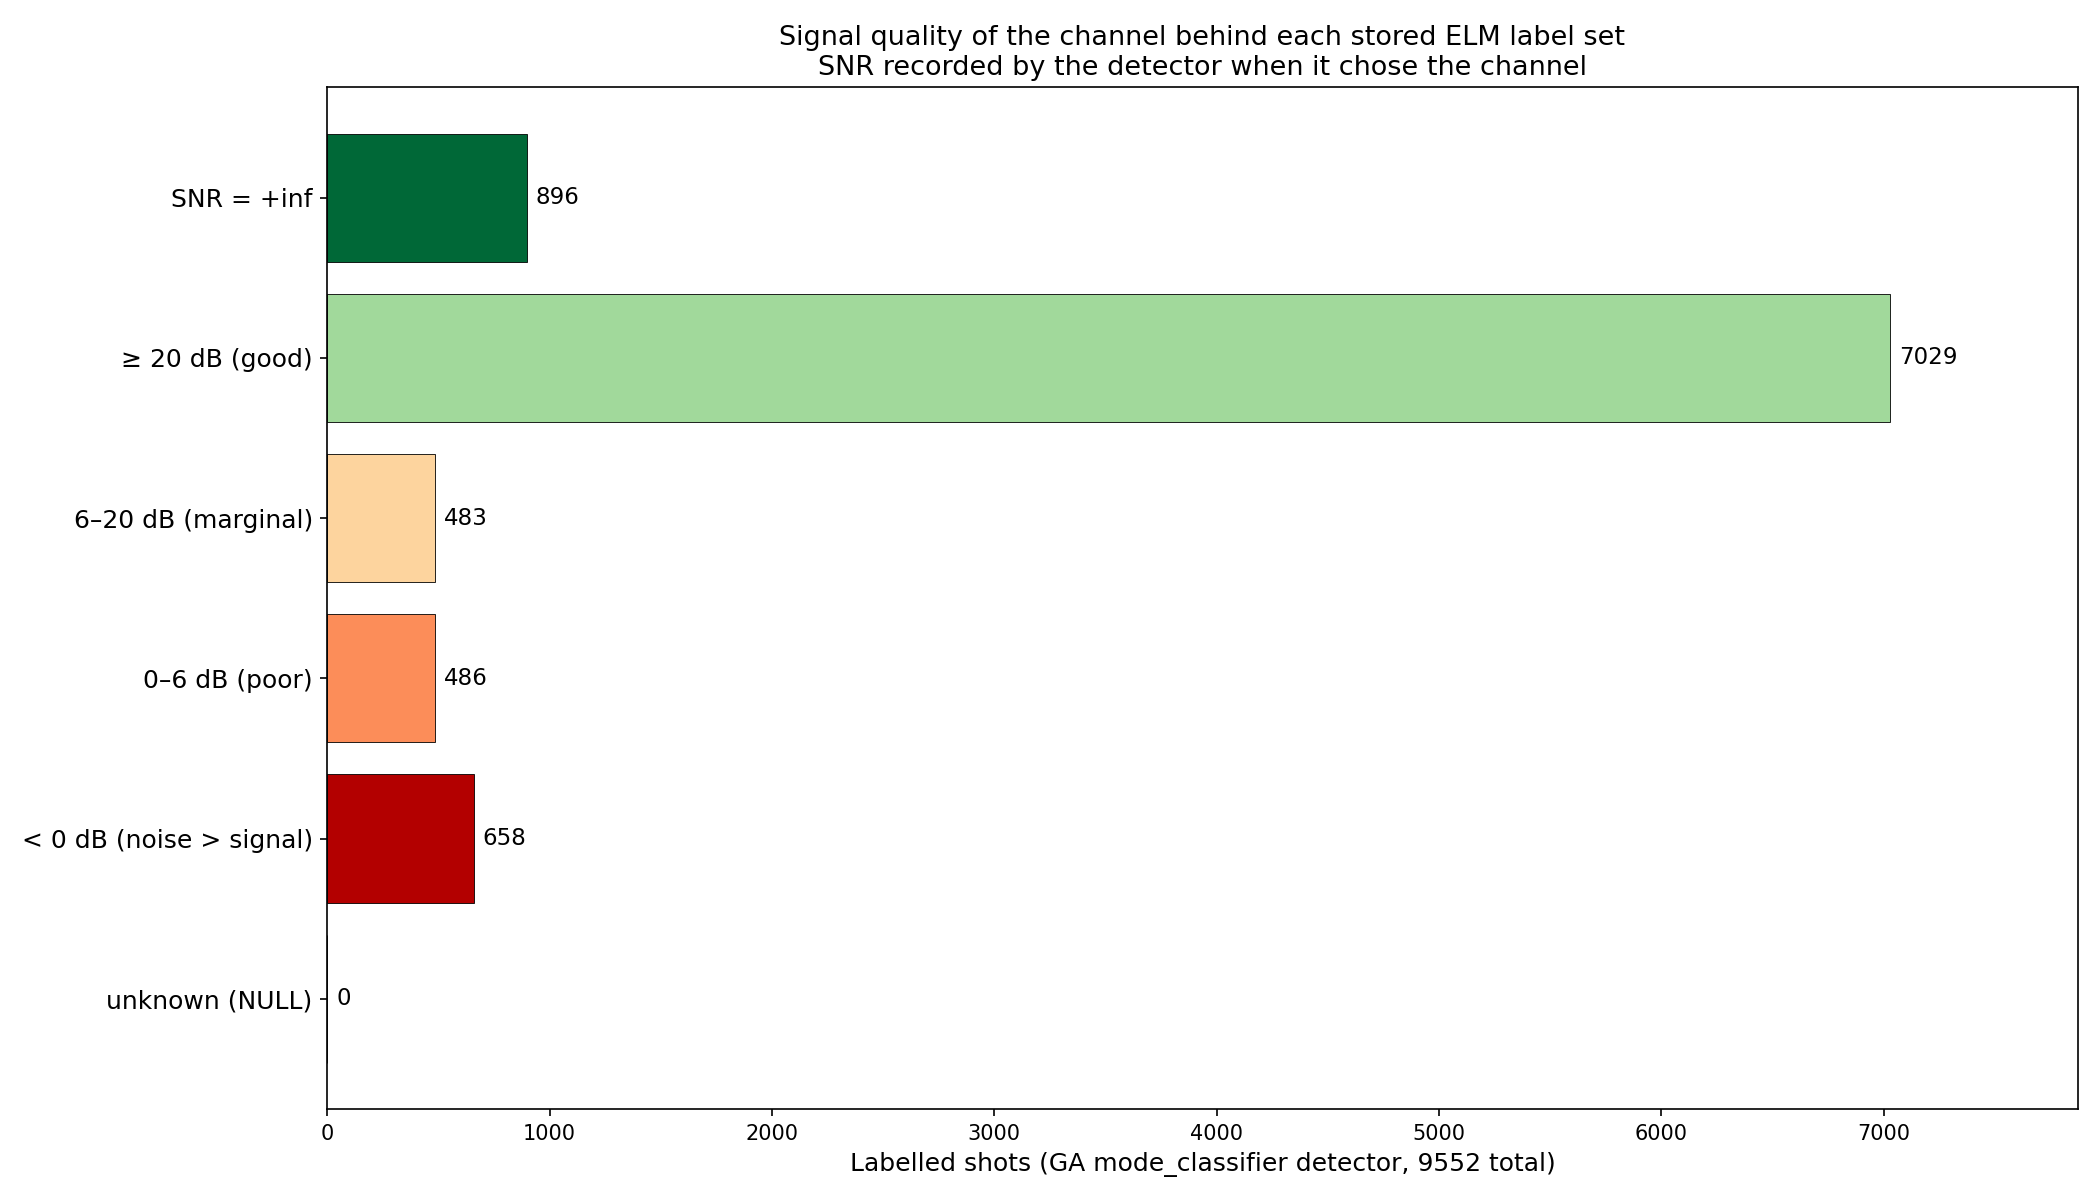

### Caveats — what these bands do and do not cover

- **The expert hand-made labels carry no SNR and no channel at all** (a person classified them; 397 regime shots, 17 event shots). They do not inherit the GA detector's noise problem — the expert looked at the traces directly — but they also cannot be quality-screened by anything in the index. 77 of the 397 regime shots were never even checked for filterscope availability.
- **Cross-method comparisons on noise-poor shots are one-sided.** Three expert-event shots have poor GA SNR — 165703 (−6.5 dB), 192048 (−12.1 dB), 171322 (+∞) — the expert side of those comparisons stands, the GA side does not.
- **OMFIT's four zeros are failures, not agreement** : it crashed with "object arrays are not supported" on 165703, 180445, 192855 and 207788; do not read those as confirming a null.
- Screened out entirely (not "caution" — no labels exist): the 300 rate-limited shots and 856 no-channel shots from earlier analyses.
- All of this rests on one quality scalar per shot. A negative-SNR label is *unverifiable from that channel*, not proven false — some may be real ELMs surviving on a noisy trace.

If you want to adjudicate rather than just flag, I can fetch the raw D-alpha traces for the highest-stakes offenders — 180445 (the no-plasma control with 543 labels), 188421, 131430 and a few ordinary-looking negative-SNR shots — and plot trace against labels. Measured cost: ~31 MB transferred (~9.6 MB decoded), ~1.4 s per shot. Shall I?

In [3]:
%%ask --review
Which shots in the ELM index have labels that I should treat with caution
because the signal quality was poor? Explain what makes them questionable.

---
# D. Questions where the honest answer is a refusal

A system that always produces a confident answer cannot be trusted. Both cells
below ask questions whose correct response is a refusal or a heavily qualified
answer. **A fluent, confident number here is a failure, not a success.**

## A shot that has not been analysed

Absence of a label is not absence of ELMs. As coverage grows, which shots are
un-analysed changes, so the question below asks the system to pick one rather
than naming a shot that may since have been processed.

**Right:** a refusal — the shot has not been analysed, so nothing is known
about its ELMs, and this is distinct from having been analysed and found quiet.

**Wrong:** any number, or "this shot has no ELMs".

In [4]:
%%ask --review
Choose a DIII-D shot that no method in this system has labelled, then tell me
how many ELMs were detected in it.

I'll plan this, then consult the skill and its learnings before querying.

Reading the skill file and its learnings before touching the index.

Skill header and learnings loaded. Reading the remainder of the skill file.

Continuing through the rest of the skill file.

Reading the final section of the skill file.

...

Appending the two new lessons after the final line.

Exact-match edits keep failing on this file — using a small Python script to append the lessons instead.

Running the append script and confirming the tail.

Lessons recorded. Completing the plan and delivering the report.

## Shot 146160: the number of ELMs detected in it is zero — because nothing has ever looked at it

**Chosen shot: 146160** , selected as follows. I took the 46,689 real plasma discharges from shot 130882 onward (the fast-digitizer era, where usable D-alpha data actually exists; count from the DIII-D shot database, not shot numbers), removed every shot touched by any of the five label sets, and took the first survivor. 146160 is the leading edge of a never-analysed block (146160–146169 and beyond).

**What was verified for 146160** : zero rows in every one of the five stored label sets — the GA mode_classifier detector (both its products, ELMy phases and individual ELMs), the expert hand-made regime labels, the expert hand-marked ELM events, and the OMFIT ELM detector. No labels exist for it under any method, and its filterscope availability has never even been checked.

**So: how many ELMs were detected? Zero — and that zero is unmeasured, not physical.** No detector has ever been run on this discharge, so the stored count is empty. This is not evidence the shot had no ELMs; it is the absence of a measurement. The contrast that makes the distinction concrete: **127 shots in this system were analysed and honestly came back with nothing found** (131937, 134192, 135582, …) — for those, "zero detections" is a claim by a named method. 146160 is not one of them; nothing has been asserted about it at all.

**Scale of the gap** : 36,311 of the 46,689 real plasma shots in the fast-digitizer era (78%) are in the same state as 146160 — never analysed by any method. The 10,917 shots that have been checked are a growing, non-uniform subset of the archive, not a census.

**Why I have not simply counted the ELMs myself** : deciding what counts as an ELM is the physics work this system deliberately leaves to named detectors. A count from code written on the spot has no provenance, cannot be compared with anything else in the label index, and — when this has been tried — over-counted by roughly six times. GA's `mode_classifier` detector is not installed in this environment, so I cannot produce a comparable label for 146160 here either.

What I can do is fetch its raw D-alpha filterscope trace — measured cost: **31.0 MB transferred (~9.6 MB decoded), about 1.4 s** — and plot it so you can see the ELM spikes directly, and confirm which channels exist for the shot and at what rate. That answers "what does the signal look like" but not "how many ELMs, by a defined method". Shall I fetch it?

## A population statistic from a non-uniform sample

**Correct:** a figure accompanied by the warning that the indexed shots are not a
uniform sample of DIII-D — a validation set concentrated in one shot era was
added deliberately — so any proportion computed over the whole index is skewed,
and the vast majority of the archive has never been analysed.

**Wrong:** a bare percentage presented as a property of DIII-D.

In [5]:
%%ask --review
What fraction of DIII-D shots are ELMy?

The skill addresses this exact question head-on in Rule 5 — the binary "labeled/not" cannot answer it — but there are real quantitative anchors to compute: the honest-none rate, the expert ground-truth fractions, and magnitude-based activity tiers. Writing the analysis script.

Dead leftover fragment referencing an undefined variable — removing it so the clean union loop below is the only path.

Fixed. Re-running the analysis.

The headliners are in. One more decisive query: in the exhaustively-checked decade, does the detector's binary still read ~98% (proving it carries no ELMy/not-ELMy information), and how many expert-quiescent-only shots did the detector nevertheless label?

All key numbers are in. One final verification run for the population firing-rate ratio so that figure is quoted from live output, not memory.

The skill's Learnings file lives under `.sage_learnings`, not in the skill directory — checking it before recording this task's lesson.

The exact-match failed; using a shorter unique anchor at the end of that entry instead.

## What fraction of DIII-D shots are ELMy? The stored labels cannot answer that as a binary — here is exactly why, and what they can say instead

**The naive number — 98.8% — is not an ELMy fraction, it is the detector's firing rate.** Of 10,840 shots the GA mode_classifier detector analysed (individual-ELM run, the only set with population coverage), 9,552 were labelled and 119 came back with genuinely nothing found: 98.8% labelled vs 1.2% honest negatives. But `labeled` means "D-alpha transients were detected", not "this was an ELMy discharge". Three independent checks in the data show the binary carries essentially no ELMy/not-ELMy information:

- **Validation against ground truth** : run on discharges the domain expert hand-labelled as QH-mode — a regime that by definition has no ELMs — the detector labelled every single one, and it fires 3.96 events/s inside expert-marked quiescent time vs 34.23/s inside ELMy H (8.6× ratio over 320 overlapping shots). On the 77 expert-labelled shots with *no* ELMy H window anywhere, the detector's 3 overlapping runs all returned `labeled`.
- **The fraction never moves** : in the exhaustively-checked 130000 decade it is 98.4%; in the 140000s it is 99.2%; across the whole index 98.8%. A classifier that returns ~99% regardless of sample cannot be measuring ELMy-ness.
- **Even a no-plasma control shot gets labelled** : shot 180445 (no plasma) received 543 ELM labels.

So the correct headline is the skill's own verdict: no denominator rescues this — the one label set covering the population is not an ELMy/not-ELMy classification.

### What the labels *can* say, each on its stated basis

**Basis 1 — the only honest "not ELMy" claims (detector, all 10,840 analysed)** : 119 shots (1.2%) were analysed and found genuinely nothing. That is the sole archive of verified quiet discharges in the system, and it is surely an under-count (the detector over-fires rather than under-fires). The other 1,169 analysed shots without labels failed for data reasons (856 no data, 313 unusable signal) — those assert nothing.

**Basis 2 — expert ground truth, shot-level (397 shots hand-labelled)** : **320 of 397 (80.6%) have at least one ELMy H window** ; 77 have none (quiescent regimes only). This is the closest thing to a true ELMy/not-ELMy classification in the system — but it is a hand-picked sample selected largely for quiescent-mode study (QH 471 windows, WPQH 260, BBQH 126 vs ELMy H 1,476), so if anything it *under*-states ELMy prevalence, and it is 0.4% of the archive, not a survey.

**Basis 3 — expert ground truth, time-weighted** : "is ELMy" is mostly a question of degree. Across the 397 expert-labelled shots, the median ELMy H time is **383 ms — 6.4% of a 6-second discharge** (mean 812 ms, 13.5%). Most shots the expert called ELMy were ELMy for a small fraction of their duration.

**Basis 4 — magnitude tiers (detector, 9,552 labelled shots; over-counts, but ranks activity)** : total ELMy-phase time per shot — median 2,268 ms, p25 1,055, p75 3,483, p95 4,598:

| ELMy time per shot | Shots | Share of labelled |
|---|---|---|
| < 100 ms (ephemeral) | 629 | 6.6% |
| 100–1000 ms | 1,642 | 17.2% |
| 1–3 s | 3,829 | 40.1% |
| 3–5 s | 3,227 | 33.8% |
| ≥ 5 s | 225 | 2.4% |

So **76.2% of labelled shots show ≥1 s of ELMy-phase activity and 36.2% show ≥3 s** — a graded statement the binary cannot make. Individual-ELM counts: median 114 per shot; only 5.7% have fewer than 5.

### Denominators, honestly

The index holds 10,917 of the archive's **90,418 plasma shots (~12%)** , built in non-uniform batches — thin strides in old eras, exhaustive only in the 130000s–140000s — so *no* percentage above is archive-representative. The question is only meaningful from shot 130882 onward (46,689 shots, the fast-digitizer era; before that the D-alpha data cannot resolve ELMs). Within that era, 9,629 distinct shots carry labels from any method (9,552 detector + 77 expert-only).

**Bottom line** : on the evidence in this system, "essentially every shot with readable fast D-alpha shows some ELM-like transient activity" (~99% detector-labelled) and "the typical shot the expert examined spends only ~6% of its time actually ELMing" are both true — the question's binary framing sits between them, and answering it archive-wide would need an ELMy/not-ELMy classification that no stored run produces.

I can make one concrete move toward an archive-wide answer: draw a random sample of the never-analysed fast-era shots — say 100 of the 36,311 — fetch their D-alpha traces (**~3.1 GB transferred, ~2.3 min serial, ~1.4 min with 8 workers** ) and check availability and show the traces, giving an unbiased eyeball-level estimate. I cannot attach comparable detector labels to them here (GA's detector is not installed in this image). Shall I?

---
## Reading the results

- **Counts are over analysed shots, not over DIII-D.** A count of labelled
  shots is a count of those processed so far, never a statement about the
  machine's history. The totals change as coverage grows; the shape of the
  answers should not.
- **All times are milliseconds.** A discharge running 0–6000 is 6 seconds long.
- **Two kinds of label row.** One *interval* row is a continuous ELMy phase; one
  *burst* row is a single ELM. The large ratio between their counts is a
  parameter of how the detector groups events, not a disagreement.
- **The index grows.** Re-running these cells after more shots are analysed
  should change the numbers but not the shape of the answers.